# Fake News Classification with BERT — Full Pipeline (Colab)

Run every cell top to bottom on a **GPU runtime** (`Runtime → Change runtime type → T4 GPU`).

Unlike a notebook that hides the project inside a big encoded blob, **every
source file here is written out via a normal, readable `%%writefile` cell**
— you (or anyone reviewing this notebook) can read every line of code as you
scroll. This is the same code as the companion `bert-fake-news.zip` repo,
just laid out so a single Colab run reproduces it from scratch.

This notebook:
1. Creates the project folder structure and writes every source file (readable, not encoded)
2. Installs dependencies
3. Downloads the Fakeddit dataset
4. Runs the 42-test suite as a sanity check
5. Trains all 4 models (TF-IDF+LR, scratch-BERT, DistilBERT, BERT-base) and builds the comparison table
6. Runs the multi-seed experiment
7. Runs the data-scaling ablation
8. Runs error analysis
9. Runs Integrated Gradients, tied to the misclassified examples
10. Launches the Gradio demo
11. Zips and downloads all results

**Estimated total runtime on a free Colab T4: ~2.5–3.5 hours** (Steps 5–7 dominate). If you're short on time, run through Step 5 first (~30–40 min) for your headline comparison table, then come back for the rest.


## Step 0 — Create the project structure

In [ ]:
import os

PROJECT_ROOT = "/content/bert-fake-news"
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)

for d in [
    "app", "configs", "scripts", "notebooks", "results",
    "src", "src/data", "src/evaluation", "src/interpretability",
    "src/models", "src/training", "src/utils", "tests",
]:
    os.makedirs(d, exist_ok=True)

print("Project root:", os.getcwd())


Project root: /content/bert-fake-news


### Package `__init__.py` files

In [ ]:
%%writefile src/__init__.py



Writing src/__init__.py


In [ ]:
%%writefile src/data/__init__.py



Writing src/data/__init__.py


In [ ]:
%%writefile src/evaluation/__init__.py



Writing src/evaluation/__init__.py


In [ ]:
%%writefile src/interpretability/__init__.py



Writing src/interpretability/__init__.py


In [ ]:
%%writefile src/training/__init__.py



Writing src/training/__init__.py


In [ ]:
%%writefile src/utils/__init__.py



Writing src/utils/__init__.py


In [ ]:
%%writefile tests/__init__.py



Writing tests/__init__.py


### `src/models/` — the from-scratch BERT implementation

In [ ]:
%%writefile src/models/attention.py
"""Multi-Head Self-Attention implemented from scratch (Vaswani et al., 2017)."""
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadSelfAttention(nn.Module):
    """Scaled Dot-Product Multi-Head Attention.

    For each head h (h = 0 .. H-1):
        head_h = Attention(X.W_Q_h, X.W_K_h, X.W_V_h)
               = softmax( Q.K^T / sqrt(d_k) ) . V
    Full output = Concat(head_0, ..., head_{H-1}) . W_O

    Args:
        embed_dim: model dimension (d_model).
        num_heads: number of attention heads H. Must divide embed_dim.
        dropout: dropout applied to attention weights.
    """

    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        if embed_dim % num_heads != 0:
            raise ValueError(
                f"embed_dim={embed_dim} must be divisible by num_heads={num_heads}"
            )

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = math.sqrt(self.head_dim)

        self.W_q = nn.Linear(embed_dim, embed_dim, bias=True)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=True)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=True)
        self.W_o = nn.Linear(embed_dim, embed_dim, bias=True)
        self.attn_dropout = nn.Dropout(dropout)

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(batch, seq_len, embed_dim) -> (batch, num_heads, seq_len, head_dim)."""
        batch, seq_len, _ = x.size()
        return x.view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

    def forward(
        self,
        x: torch.Tensor,  # (batch, seq_len, embed_dim)
        attention_mask: torch.Tensor = None,  # (batch, seq_len), 1=keep 0=pad
        return_attn_weights: bool = False,
    ):
        batch, seq_len, _ = x.size()

        Q = self.split_heads(self.W_q(x))  # (batch, heads, seq, head_dim)
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale  # (batch, heads, seq, seq)

        if attention_mask is not None:
            extended_mask = attention_mask[:, None, None, :].float()
            scores = scores + (1.0 - extended_mask) * -1e9

        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        context = torch.matmul(attn_weights, V)  # (batch, heads, seq, head_dim)
        context = context.transpose(1, 2).contiguous().view(batch, seq_len, self.embed_dim)

        output = self.W_o(context)
        if return_attn_weights:
            return output, attn_weights
        return output


Writing src/models/attention.py


In [ ]:
%%writefile src/models/feedforward.py
"""Position-wise Feed-Forward Network used inside each encoder block."""
import torch
import torch.nn as nn


class FeedForwardLayer(nn.Module):
    """Two-layer MLP applied identically to every token position.

        FFN(x) = GELU( x.W_1 + b_1 ).W_2 + b_2

    BERT uses GELU (not ReLU). Inner dimension is conventionally 4 * embed_dim.
    """

    def __init__(self, embed_dim: int, ff_dim: int = 2048, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ff_dim)
        self.linear2 = nn.Linear(ff_dim, embed_dim)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.linear1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x


Writing src/models/feedforward.py


In [ ]:
%%writefile src/models/embeddings.py
"""BERT-style input embeddings: token + positional + segment."""
import torch
import torch.nn as nn


class BertEmbeddings(nn.Module):
    """Combines token, positional and segment embeddings.

        combined = TokenEmb(input_ids) + PositionEmb(0..seq_len-1) + SegmentEmb(token_type_ids)
        output   = Dropout( LayerNorm( combined ) )

    All three tables are learned (as in the original BERT paper), unlike the
    sinusoidal positions used in the vanilla Transformer.
    """

    def __init__(
        self,
        vocab_size: int = 30522,
        embed_dim: int = 512,
        max_pos: int = 512,
        type_vocab: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.token_embeddings = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.position_embeddings = nn.Embedding(max_pos, embed_dim)
        self.segment_embeddings = nn.Embedding(type_vocab, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("position_ids", torch.arange(max_pos).unsqueeze(0))

    def forward(self, input_ids: torch.Tensor, token_type_ids: torch.Tensor = None):
        _, seq_len = input_ids.size()

        tok_emb = self.token_embeddings(input_ids)
        pos_emb = self.position_embeddings(self.position_ids[:, :seq_len])

        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)
        seg_emb = self.segment_embeddings(token_type_ids)

        combined = tok_emb + pos_emb + seg_emb
        combined = self.norm(combined)
        combined = self.dropout(combined)
        return combined, tok_emb, pos_emb, seg_emb


Writing src/models/embeddings.py


In [ ]:
%%writefile src/models/encoder.py
"""Transformer encoder block and BERT pooler."""
import torch
import torch.nn as nn

from .attention import MultiHeadSelfAttention
from .feedforward import FeedForwardLayer


class TransformerEncoderLayer(nn.Module):
    """One BERT encoder block with Post-LayerNorm (original BERT paper).

        Sub-layer 1:  out1 = LayerNorm( x + Dropout( MHSA(x) ) )
        Sub-layer 2:  out2 = LayerNorm( out1 + Dropout( FFN(out1) ) )

    Returns the block output plus the pre-residual MHSA/FFN outputs so their
    shapes can be logged / inspected (used by Task 1's shape report).
    """

    def __init__(self, embed_dim: int, num_heads: int, ff_dim: int = 2048, dropout: float = 0.1):
        super().__init__()
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.feed_forward = FeedForwardLayer(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None):
        attn_out = self.attention(x, attention_mask)
        x = self.norm1(x + self.dropout(attn_out))

        ff_out = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x, attn_out, ff_out


class BertPooler(nn.Module):
    """Extracts the [CLS] hidden state and passes it through Dense + Tanh."""

    def __init__(self, embed_dim: int):
        super().__init__()
        self.dense = nn.Linear(embed_dim, embed_dim)
        self.activation = nn.Tanh()

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        cls_hidden = hidden_states[:, 0, :]
        return self.activation(self.dense(cls_hidden))


Writing src/models/encoder.py


In [ ]:
%%writefile src/models/bert.py
"""Encoder-only BERT implemented from scratch, with a classification head."""
import torch
import torch.nn as nn

from .embeddings import BertEmbeddings
from .encoder import BertPooler, TransformerEncoderLayer


class BertModel(nn.Module):
    """Encoder-only BERT built from scratch.

    Data flow:
        input_ids
          -> BertEmbeddings   (token + position + segment)
          -> N x TransformerEncoderLayer
          -> BertPooler       ([CLS] vector)
          -> Dropout + Linear (classifier head)
          -> logits

    Default hyperparameters match the assignment spec (embed_dim=512,
    num_heads=8, num_layers=2), but the class is fully configurable so it can
    be used in the model-size / data-scaling ablations.
    """

    def __init__(
        self,
        vocab_size: int = 30522,
        embed_dim: int = 512,
        num_heads: int = 8,
        num_layers: int = 2,
        ff_dim: int = 2048,
        max_pos: int = 512,
        num_classes: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.embeddings = BertEmbeddings(vocab_size, embed_dim, max_pos, 2, dropout)
        self.encoder_layers = nn.ModuleList(
            [
                TransformerEncoderLayer(embed_dim, num_heads, ff_dim, dropout)
                for _ in range(num_layers)
            ]
        )
        self.pooler = BertPooler(embed_dim)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes),
        )

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        token_type_ids: torch.Tensor = None,
    ) -> dict:
        combined, tok_emb, pos_emb, seg_emb = self.embeddings(input_ids, token_type_ids)

        h = combined
        enc_outputs, attn_outputs, ff_outputs = [], [], []
        for layer in self.encoder_layers:
            h, attn_out, ff_out = layer(h, attention_mask)
            enc_outputs.append(h)
            attn_outputs.append(attn_out)
            ff_outputs.append(ff_out)

        pooled = self.pooler(h)
        logits = self.classifier(pooled)

        return {
            "logits": logits,
            "pooled_output": pooled,
            "last_hidden_state": h,
            "enc_outputs": enc_outputs,
            "attn_outputs": attn_outputs,
            "ff_outputs": ff_outputs,
            "token_embeddings": tok_emb,
            "position_embeddings": pos_emb,
            "segment_embeddings": seg_emb,
            "combined_embeddings": combined,
        }


Writing src/models/bert.py


In [ ]:
%%writefile src/models/__init__.py
from .attention import MultiHeadSelfAttention
from .feedforward import FeedForwardLayer
from .embeddings import BertEmbeddings
from .encoder import TransformerEncoderLayer, BertPooler
from .bert import BertModel

__all__ = [
    "MultiHeadSelfAttention",
    "FeedForwardLayer",
    "BertEmbeddings",
    "TransformerEncoderLayer",
    "BertPooler",
    "BertModel",
]


Writing src/models/__init__.py


### `src/data/` — Fakeddit preprocessing and PyTorch Dataset

In [ ]:
%%writefile src/data/preprocess.py
"""Load, clean, balance and split the Fakeddit dataset.

Expects the three official TSVs (all_train.tsv, all_validate.tsv,
all_test_public.tsv) to already be present on disk -- see README.md /
NEXT_STEPS.md for where to get them. This module does not download data
itself so it stays usable in offline / restricted-network environments.
"""
from __future__ import annotations

import os
from dataclasses import dataclass

import pandas as pd
from sklearn.model_selection import train_test_split


@dataclass
class DatasetStats:
    original_total: int
    original_fake: int
    original_real: int
    balanced_total: int
    train_size: int
    test_size: int


def load_and_combine(data_dir: str, file_names=None) -> pd.DataFrame:
    """Load and concatenate the three Fakeddit TSVs."""
    file_names = file_names or ["all_train.tsv", "all_validate.tsv", "all_test_public.tsv"]
    paths = [os.path.join(data_dir, f) for f in file_names]
    missing = [p for p in paths if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError(
            f"Missing Fakeddit files: {missing}. See NEXT_STEPS.md for download instructions."
        )
    dfs = [pd.read_csv(p, sep="\t", on_bad_lines="skip", low_memory=False) for p in paths]
    return pd.concat(dfs, ignore_index=True)


def _detect_title_column(df: pd.DataFrame) -> str:
    for col in df.columns:
        if "clean" in col.lower() and "title" in col.lower():
            return col
    for col in df.columns:
        if col.lower() == "title":
            return col
    raise ValueError("Could not find a title column in the dataset.")


def clean(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Keep only clean_title / label / id, drop nulls and near-empty titles."""
    title_col = _detect_title_column(raw_df)
    needed = [c for c in [title_col, "2_way_label", "id"] if c in raw_df.columns]
    df = raw_df[needed].copy()
    df.rename(columns={title_col: "clean_title", "2_way_label": "label"}, inplace=True)

    df.dropna(subset=["clean_title", "label"], inplace=True)
    df["clean_title"] = df["clean_title"].astype(str).str.strip()
    df = df[df["clean_title"].str.len() > 3].copy()
    df["label"] = df["label"].astype(int)
    df.reset_index(drop=True, inplace=True)
    return df


def balance(df: pd.DataFrame, n_per_class: int = 2500, seed: int = 42) -> pd.DataFrame:
    """Randomly sample n_per_class rows from each label to build a balanced set."""
    fake_df = df[df["label"] == 1].sample(n=n_per_class, random_state=seed)
    real_df = df[df["label"] == 0].sample(n=n_per_class, random_state=seed)
    return (
        pd.concat([fake_df, real_df], ignore_index=True)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )


def split(df: pd.DataFrame, test_size: float = 0.2, seed: int = 42):
    """Stratified 80/20 (default) train/test split, keeps classes balanced in both."""
    train_df, test_df = train_test_split(
        df, test_size=test_size, random_state=seed, stratify=df["label"]
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)


def prepare_dataset(
    data_dir: str,
    n_per_class: int = 2500,
    test_size: float = 0.2,
    seed: int = 42,
    train_fraction: float = 1.0,
):
    """Full pipeline: load -> clean -> balance -> split.

    train_fraction: keep only this fraction of the *training* split (stratified),
    used for the data-scaling ablation (10% / 25% / 50% / 100%). Test set is
    always kept at full size so results across fractions are comparable.
    """
    raw_df = load_and_combine(data_dir)
    df = clean(raw_df)
    balanced_df = balance(df, n_per_class=n_per_class, seed=seed)
    train_df, test_df = split(balanced_df, test_size=test_size, seed=seed)

    if train_fraction < 1.0:
        train_df, _ = train_test_split(
            train_df,
            train_size=train_fraction,
            random_state=seed,
            stratify=train_df["label"],
        )
        train_df = train_df.reset_index(drop=True)

    stats = DatasetStats(
        original_total=len(df),
        original_fake=int((df["label"] == 1).sum()),
        original_real=int((df["label"] == 0).sum()),
        balanced_total=len(balanced_df),
        train_size=len(train_df),
        test_size=len(test_df),
    )
    return train_df, test_df, stats


Writing src/data/preprocess.py


In [ ]:
%%writefile src/data/dataset.py
"""PyTorch Dataset wrapping a tokenizer over the Fakeddit title/label pairs."""
import pandas as pd
import torch
from torch.utils.data import Dataset


class FakedditDataset(Dataset):
    """Each item returns input_ids/attention_mask/token_type_ids/label tensors.

    Padding: right-padding to max_len with [PAD]=0.
    Truncation: right-truncation to max_len tokens.
    """

    def __init__(self, dataframe: pd.DataFrame, tokenizer, max_len: int):
        self.texts = dataframe["clean_title"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "token_type_ids": torch.zeros(self.max_len, dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }


Writing src/data/dataset.py


### `src/utils/`

In [ ]:
%%writefile src/utils/seed.py
"""Reproducibility helpers."""
import random

import numpy as np
import torch


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


Writing src/utils/seed.py


### `src/training/` — training engine and CLI scripts

In [ ]:
%%writefile src/training/engine.py
"""Shared training / evaluation loops.

Works with both our from-scratch BertModel (which returns a dict with a
'logits' key) and HuggingFace models (which return an object with a .logits
attribute), via the `get_logits` helper.
"""
import torch
import torch.nn as nn


def get_logits(outputs):
    if isinstance(outputs, dict):
        return outputs["logits"]
    return outputs.logits


def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device, log_every=20):
    model.train()
    total_loss, n_correct, n_total = 0.0, 0, 0

    for step, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        logits = get_logits(outputs)
        loss = loss_fn(logits, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        n_correct += (preds == labels).sum().item()
        n_total += labels.size(0)

        if log_every and (step + 1) % log_every == 0:
            print(
                f"  Step {step + 1:>4}/{len(loader)} "
                f"| Loss: {total_loss / (step + 1):.4f} "
                f"| Acc: {n_correct / n_total:.4f}"
            )

    return total_loss / len(loader), n_correct / n_total


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, n_correct, n_total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        logits = get_logits(outputs)
        loss = loss_fn(logits, labels)
        preds = logits.argmax(dim=-1)

        total_loss += loss.item()
        n_correct += (preds == labels).sum().item()
        n_total += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    return total_loss / len(loader), n_correct / n_total, all_preds, all_labels


Writing src/training/engine.py


In [ ]:
%%writefile src/training/train_baseline.py
"""TF-IDF + Logistic Regression baseline.

Usage:
    python -m src.training.train_baseline --data_dir data/fakeddit --out_dir results/baseline
"""
import argparse
import os
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from src.data.preprocess import prepare_dataset
from src.evaluation.metrics import compute_metrics, plot_confusion_matrix, save_metrics
from src.utils.seed import set_seed


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data_dir", type=str, required=True)
    ap.add_argument("--out_dir", type=str, default="results/baseline")
    ap.add_argument("--n_per_class", type=int, default=2500)
    ap.add_argument("--seed", type=int, default=42)
    ap.add_argument("--max_features", type=int, default=20000)
    args = ap.parse_args()

    set_seed(args.seed)
    os.makedirs(args.out_dir, exist_ok=True)

    train_df, test_df, stats = prepare_dataset(args.data_dir, n_per_class=args.n_per_class, seed=args.seed)
    print(f"Train: {stats.train_size} | Test: {stats.test_size}")

    vectorizer = TfidfVectorizer(max_features=args.max_features, ngram_range=(1, 2), stop_words="english")
    X_train = vectorizer.fit_transform(train_df["clean_title"])
    X_test = vectorizer.transform(test_df["clean_title"])

    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=args.seed)
    t0 = time.time()
    clf.fit(X_train, train_df["label"])
    train_time = time.time() - t0

    preds = clf.predict(X_test)
    metrics = compute_metrics(test_df["label"].tolist(), preds.tolist())

    print(f"Accuracy: {metrics['accuracy']:.4f} | F1: {metrics['f1_weighted']:.4f}")
    print(metrics["classification_report"])

    plot_confusion_matrix(
        metrics["confusion_matrix"],
        os.path.join(args.out_dir, "confusion_matrix.png"),
        title="TF-IDF + Logistic Regression -- Confusion Matrix",
    )
    save_metrics(
        metrics,
        os.path.join(args.out_dir, "metrics.json"),
        extra={"model": "tfidf_logreg", "train_time_sec": train_time, "seed": args.seed},
    )
    print(f"Saved results to {args.out_dir}/")


if __name__ == "__main__":
    main()


Writing src/training/train_baseline.py


In [ ]:
%%writefile src/training/train_scratch.py
"""Train the from-scratch BertModel (Task 1 architecture) on Fakeddit.

Usage:
    python -m src.training.train_scratch --data_dir data/fakeddit --out_dir results/scratch_bert
"""
import argparse
import os

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import BertTokenizer, get_linear_schedule_with_warmup

from src.data.dataset import FakedditDataset
from src.data.preprocess import prepare_dataset
from src.evaluation.metrics import (
    compute_metrics,
    plot_confusion_matrix,
    plot_training_curves,
    save_metrics,
)
from src.models.bert import BertModel
from src.training.engine import evaluate, train_one_epoch
from src.utils.seed import set_seed


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data_dir", type=str, required=True)
    ap.add_argument("--out_dir", type=str, default="results/scratch_bert")
    ap.add_argument("--n_per_class", type=int, default=2500)
    ap.add_argument("--max_len", type=int, default=64)
    ap.add_argument("--batch_size", type=int, default=32)
    ap.add_argument("--epochs", type=int, default=6)
    ap.add_argument("--lr", type=float, default=1e-4)
    ap.add_argument("--embed_dim", type=int, default=512)
    ap.add_argument("--num_heads", type=int, default=8)
    ap.add_argument("--num_layers", type=int, default=2)
    ap.add_argument("--seed", type=int, default=42)
    args = ap.parse_args()

    set_seed(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(args.out_dir, exist_ok=True)

    train_df, test_df, stats = prepare_dataset(args.data_dir, n_per_class=args.n_per_class, seed=args.seed)
    print(f"Train: {stats.train_size} | Test: {stats.test_size}")

    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    train_loader = DataLoader(
        FakedditDataset(train_df, tokenizer, args.max_len), batch_size=args.batch_size, shuffle=True
    )
    test_loader = DataLoader(
        FakedditDataset(test_df, tokenizer, args.max_len), batch_size=args.batch_size
    )

    model = BertModel(
        vocab_size=tokenizer.vocab_size,
        embed_dim=args.embed_dim,
        num_heads=args.num_heads,
        num_layers=args.num_layers,
        ff_dim=args.embed_dim * 4,
        num_classes=2,
    ).to(device)

    total_steps = len(train_loader) * args.epochs
    optimizer = AdamW(model.parameters(), lr=args.lr, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )
    loss_fn = nn.CrossEntropyLoss()

    train_losses, train_accs, test_losses, test_accs = [], [], [], []
    for epoch in range(1, args.epochs + 1):
        print(f"Epoch {epoch}/{args.epochs}")
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, scheduler, loss_fn, device)
        te_loss, te_acc, _, _ = evaluate(model, test_loader, loss_fn, device)
        train_losses.append(tr_loss)
        train_accs.append(tr_acc)
        test_losses.append(te_loss)
        test_accs.append(te_acc)
        print(f"  train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} test_loss={te_loss:.4f} test_acc={te_acc:.4f}")

    _, _, preds, labels = evaluate(model, test_loader, loss_fn, device)
    metrics = compute_metrics(labels, preds)
    print(f"Final Accuracy: {metrics['accuracy']:.4f} | F1: {metrics['f1_weighted']:.4f}")

    plot_training_curves(
        train_losses, test_losses, train_accs, test_accs,
        os.path.join(args.out_dir, "training_curves.png"),
    )
    plot_confusion_matrix(
        metrics["confusion_matrix"],
        os.path.join(args.out_dir, "confusion_matrix.png"),
        title="Scratch BERT -- Confusion Matrix",
    )
    save_metrics(
        metrics,
        os.path.join(args.out_dir, "metrics.json"),
        extra={"model": "scratch_bert", "seed": args.seed, "hyperparams": vars(args)},
    )

    torch.save(model.state_dict(), os.path.join(args.out_dir, "model_state_dict.pt"))
    print(f"Saved results and checkpoint to {args.out_dir}/")


if __name__ == "__main__":
    main()


Writing src/training/train_scratch.py


In [ ]:
%%writefile src/training/train_transformer.py
"""Fine-tune a HuggingFace BertForSequenceClassification-style model.

Works for bert-base-uncased, distilbert-base-uncased, roberta-base, etc.
Supports --seed (multi-seed reporting) and --train_fraction (data-scaling
ablation) so the SAME script drives Task 3, the multi-seed experiment, and
the data-scaling experiment -- just with different CLI flags.

Usage:
    python -m src.training.train_transformer \
        --data_dir data/fakeddit --model_name bert-base-uncased \
        --out_dir results/bert_base --seed 42

    # data-scaling ablation point at 25% of training data
    python -m src.training.train_transformer \
        --data_dir data/fakeddit --model_name bert-base-uncased \
        --out_dir results/bert_base_25pct --train_fraction 0.25
"""
import argparse
import os

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

from src.data.dataset import FakedditDataset
from src.data.preprocess import prepare_dataset
from src.evaluation.error_analysis import build_error_report, category_counts
from src.evaluation.metrics import (
    compute_metrics,
    plot_confusion_matrix,
    plot_training_curves,
    save_metrics,
)
from src.training.engine import evaluate, train_one_epoch
from src.utils.seed import set_seed


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data_dir", type=str, required=True)
    ap.add_argument("--model_name", type=str, default="bert-base-uncased")
    ap.add_argument("--out_dir", type=str, default="results/bert_base")
    ap.add_argument("--n_per_class", type=int, default=2500)
    ap.add_argument("--max_len", type=int, default=64)
    ap.add_argument("--batch_size", type=int, default=32)
    ap.add_argument("--epochs", type=int, default=4)
    ap.add_argument("--lr", type=float, default=2e-5)
    ap.add_argument("--weight_decay", type=float, default=0.01)
    ap.add_argument("--warmup_ratio", type=float, default=0.1)
    ap.add_argument("--seed", type=int, default=42)
    ap.add_argument("--train_fraction", type=float, default=1.0, help="fraction of TRAIN split to use (data-scaling ablation)")
    ap.add_argument("--save_model", action="store_true")
    args = ap.parse_args()

    set_seed(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(args.out_dir, exist_ok=True)

    train_df, test_df, stats = prepare_dataset(
        args.data_dir, n_per_class=args.n_per_class, seed=args.seed, train_fraction=args.train_fraction
    )
    print(f"Train: {stats.train_size} | Test: {stats.test_size} | train_fraction={args.train_fraction}")

    tokenizer = AutoTokenizer.from_pretrained(args.model_name)
    train_loader = DataLoader(
        FakedditDataset(train_df, tokenizer, args.max_len), batch_size=args.batch_size, shuffle=True
    )
    test_loader = DataLoader(FakedditDataset(test_df, tokenizer, args.max_len), batch_size=args.batch_size)

    model = AutoModelForSequenceClassification.from_pretrained(args.model_name, num_labels=2).to(device)

    no_decay = ["bias", "LayerNorm.weight"]
    param_groups = [
        {"params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)], "weight_decay": args.weight_decay},
        {"params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)], "weight_decay": 0.0},
    ]
    optimizer = AdamW(param_groups, lr=args.lr)
    total_steps = len(train_loader) * args.epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(args.warmup_ratio * total_steps), num_training_steps=total_steps
    )
    loss_fn = nn.CrossEntropyLoss()

    train_losses, train_accs, test_losses, test_accs = [], [], [], []
    for epoch in range(1, args.epochs + 1):
        print(f"Epoch {epoch}/{args.epochs}")
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, scheduler, loss_fn, device)
        te_loss, te_acc, _, _ = evaluate(model, test_loader, loss_fn, device)
        train_losses.append(tr_loss)
        train_accs.append(tr_acc)
        test_losses.append(te_loss)
        test_accs.append(te_acc)
        print(f"  train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} test_loss={te_loss:.4f} test_acc={te_acc:.4f}")

    _, _, preds, labels = evaluate(model, test_loader, loss_fn, device)
    metrics = compute_metrics(labels, preds)
    print(f"Final Accuracy: {metrics['accuracy']:.4f} | F1: {metrics['f1_weighted']:.4f}")

    plot_training_curves(train_losses, test_losses, train_accs, test_accs, os.path.join(args.out_dir, "training_curves.png"))
    plot_confusion_matrix(metrics["confusion_matrix"], os.path.join(args.out_dir, "confusion_matrix.png"), title=f"{args.model_name} -- Confusion Matrix")
    save_metrics(
        metrics,
        os.path.join(args.out_dir, "metrics.json"),
        extra={
            "model": args.model_name,
            "seed": args.seed,
            "train_fraction": args.train_fraction,
            "train_size": stats.train_size,
            "hyperparams": vars(args),
        },
    )

    errors = build_error_report(test_df, preds, labels, top_k=10)
    errors.to_csv(os.path.join(args.out_dir, "error_examples.csv"), index=False)
    print("Error category counts:\n", category_counts(errors))

    if args.save_model:
        model.save_pretrained(os.path.join(args.out_dir, "checkpoint"))
        tokenizer.save_pretrained(os.path.join(args.out_dir, "checkpoint"))

    print(f"Saved results to {args.out_dir}/")


if __name__ == "__main__":
    main()


Writing src/training/train_transformer.py


### `src/evaluation/` — metrics, error analysis, results aggregation

In [ ]:
%%writefile src/evaluation/metrics.py
"""Metric computation and result-artifact saving (JSON + plots)."""
import json
import os

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


def compute_metrics(labels, preds) -> dict:
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision_weighted": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall_weighted": recall_score(labels, preds, average="weighted", zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "confusion_matrix": confusion_matrix(labels, preds).tolist(),
        "classification_report": classification_report(
            labels, preds, target_names=["Real (0)", "Fake (1)"], zero_division=0
        ),
    }


def save_metrics(metrics: dict, out_path: str, extra: dict = None):
    payload = dict(metrics)
    if extra:
        payload.update(extra)
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    with open(out_path, "w") as f:
        json.dump(payload, f, indent=2)
    return out_path


def plot_confusion_matrix(cm, out_path: str, title: str = "Confusion Matrix"):
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted Real", "Predicted Fake"],
        yticklabels=["Actual Real", "Actual Fake"],
        ax=ax,
        linewidths=0.5,
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_path


def plot_training_curves(train_losses, test_losses, train_accs, test_accs, out_path: str):
    import matplotlib.pyplot as plt

    epochs_x = list(range(1, len(train_losses) + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs_x, train_losses, "b-o", label="Train Loss")
    ax1.plot(epochs_x, test_losses, "r-s", label="Test Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.set_title("Loss Curves")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs_x, train_accs, "b-o", label="Train Acc")
    ax2.plot(epochs_x, test_accs, "r-s", label="Test Acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Accuracy Curves")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_path


def plot_data_scaling_curve(fractions, f1_scores, out_path: str):
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot([f * 100 for f in fractions], f1_scores, "o-", linewidth=2, markersize=8)
    ax.set_xlabel("Training set size used (%)")
    ax.set_ylabel("Test F1-score")
    ax.set_title("Performance vs. Training Set Size")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_path


Writing src/evaluation/metrics.py


In [ ]:
%%writefile src/evaluation/error_analysis.py
"""Pull misclassified examples and bucket them by simple heuristic categories.

The categories are intentionally simple heuristics (length, punctuation,
lexical cues) meant as a *starting point* for manual inspection -- the
report should still eyeball the actual misclassified examples and describe
the error patterns in prose (see NEXT_STEPS.md Step 5).
"""
import pandas as pd

CLICKBAIT_CUES = {
    "shocking", "you won't believe", "wont believe", "unbelievable",
    "must see", "goes viral", "insane", "outrageous", "amazing",
}


def categorize_error(text: str) -> str:
    t = text.lower()
    n_words = len(t.split())
    if n_words <= 4:
        return "very_short_title"
    if "?" in t:
        return "question_headline"
    if any(cue in t for cue in CLICKBAIT_CUES):
        return "clickbait_language"
    if t.count("!") >= 1:
        return "exclamatory_headline"
    if n_words >= 20:
        return "long_title"
    return "other"


def build_error_report(
    test_df: pd.DataFrame,
    preds,
    labels,
    text_col: str = "clean_title",
    top_k: int = 10,
) -> pd.DataFrame:
    """Returns a DataFrame of misclassified rows with a heuristic category,
    sorted so the first `top_k` rows are good candidates to paste into the
    report as worked examples."""
    df = test_df.reset_index(drop=True).copy()
    df["true_label"] = labels
    df["pred_label"] = preds
    errors = df[df["true_label"] != df["pred_label"]].copy()
    errors["error_category"] = errors[text_col].apply(categorize_error)
    errors = errors.sample(frac=1, random_state=42).reset_index(drop=True)
    return errors.head(top_k) if top_k else errors


def category_counts(errors: pd.DataFrame) -> pd.Series:
    return errors["error_category"].value_counts()


Writing src/evaluation/error_analysis.py


In [ ]:
%%writefile src/evaluation/aggregate_results.py
"""Scan a results/ directory tree for metrics.json files and build a single
comparison table (CSV + printed markdown) across all trained models.

Usage:
    python -m src.evaluation.aggregate_results --results_dir results --out results/comparison_table.csv
"""
import argparse
import glob
import json
import os

import pandas as pd


def load_all_metrics(results_dir: str) -> pd.DataFrame:
    rows = []
    for path in glob.glob(os.path.join(results_dir, "**", "metrics.json"), recursive=True):
        with open(path) as f:
            m = json.load(f)
        rows.append(
            {
                "run_dir": os.path.relpath(os.path.dirname(path), results_dir),
                "model": m.get("model", "unknown"),
                "seed": m.get("seed"),
                "train_fraction": m.get("train_fraction", 1.0),
                "accuracy": m.get("accuracy"),
                "precision": m.get("precision_weighted"),
                "recall": m.get("recall_weighted"),
                "f1": m.get("f1_weighted"),
            }
        )
    return pd.DataFrame(rows)


def summarize_by_model(df: pd.DataFrame) -> pd.DataFrame:
    """Mean +/- std F1/accuracy per model (collapses multi-seed runs)."""
    grouped = df.groupby("model").agg(
        n_runs=("f1", "count"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
    ).reset_index()
    return grouped


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--results_dir", type=str, default="results")
    ap.add_argument("--out", type=str, default="results/comparison_table.csv")
    args = ap.parse_args()

    df = load_all_metrics(args.results_dir)
    if df.empty:
        print(f"No metrics.json files found under {args.results_dir}/. Run some training scripts first.")
        return

    df.to_csv(args.out, index=False)
    print(f"Wrote raw comparison table to {args.out}")

    summary = summarize_by_model(df)
    summary_path = os.path.splitext(args.out)[0] + "_summary.csv"
    summary.to_csv(summary_path, index=False)
    print(f"Wrote per-model summary to {summary_path}\n")
    print(summary.to_markdown(index=False))


if __name__ == "__main__":
    main()


Writing src/evaluation/aggregate_results.py


### `src/interpretability/` — Integrated Gradients

In [ ]:
%%writefile src/interpretability/integrated_gradients.py
"""Layer Integrated Gradients token attribution for the fine-tuned classifier.

Requires `captum` (pip install captum) and a fine-tuned
BertForSequenceClassification model + its tokenizer. Not covered by the CPU
unit tests in tests/ because it requires downloading bert-base-uncased and a
trained checkpoint; run it manually per NEXT_STEPS.md Step 8.
"""
from __future__ import annotations

import torch

SPECIAL_TOKENS = {"[CLS]", "[SEP]", "[PAD]"}


def make_forward_fn(model):
    """Rank-agnostic forward function for Captum: accepts either token ids
    (rank 2) or embeddings (rank 3)."""

    def forward_fn(inputs, attention_mask=None, token_type_ids=None):
        if inputs.dim() == 2:
            outputs = model(
                input_ids=inputs,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
            )
        else:
            outputs = model(
                inputs_embeds=inputs,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
            )
        return outputs.logits

    return forward_fn


def compute_ig(
    text: str,
    model,
    tokenizer,
    target_class: int,
    device: str = "cpu",
    n_steps: int = 300,
    internal_batch_size: int = 2,
    max_len: int = 64,
) -> dict:
    """Tokenise `text`, run LayerIntegratedGradients, return per-token scores.

    Baseline: all-zero embeddings. Attribution is summed over the embedding
    dimension and normalized by its L1 norm for interpretability.
    """
    from captum.attr import LayerIntegratedGradients

    model.eval()
    enc = tokenizer(text, max_length=max_len, truncation=True, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)
    token_type_ids = torch.zeros_like(input_ids)

    forward_fn = make_forward_fn(model)
    embedding_layer = model.bert.embeddings.word_embeddings
    lig = LayerIntegratedGradients(forward_fn, embedding_layer)

    baseline_ids = torch.zeros_like(input_ids)

    attributions, delta = lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(attention_mask, token_type_ids),
        target=target_class,
        n_steps=n_steps,
        internal_batch_size=internal_batch_size,
        return_convergence_delta=True,
    )

    scores = attributions.sum(dim=-1).squeeze(0)
    scores = scores / (scores.norm() + 1e-12)
    scores = scores.detach().cpu().numpy().tolist()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().tolist())

    return {
        "text": text,
        "tokens": tokens,
        "scores": scores,
        "convergence_delta": float(delta.abs().item()),
        "target_class": target_class,
    }


def top_k_tokens(result: dict, k: int = 5, exclude_special: bool = True):
    pairs = list(zip(result["tokens"], result["scores"]))
    if exclude_special:
        pairs = [(t, s) for t, s in pairs if t not in SPECIAL_TOKENS]
    return sorted(pairs, key=lambda x: abs(x[1]), reverse=True)[:k]


Writing src/interpretability/integrated_gradients.py


### `tests/` — 42 unit tests

In [ ]:
%%writefile tests/test_attention.py
import torch

from src.models.attention import MultiHeadSelfAttention


def test_output_shape_matches_input():
    batch, seq_len, embed_dim, heads = 4, 12, 64, 8
    layer = MultiHeadSelfAttention(embed_dim, heads)
    x = torch.randn(batch, seq_len, embed_dim)
    out = layer(x)
    assert out.shape == (batch, seq_len, embed_dim)


def test_rejects_non_divisible_heads():
    try:
        MultiHeadSelfAttention(embed_dim=65, num_heads=8)
        assert False, "expected ValueError for non-divisible embed_dim/num_heads"
    except ValueError:
        pass


def test_padding_mask_zeros_out_attention_to_pad_tokens():
    """A padded position should receive ~0 attention weight from real tokens."""
    torch.manual_seed(0)
    batch, seq_len, embed_dim, heads = 1, 6, 32, 4
    layer = MultiHeadSelfAttention(embed_dim, heads, dropout=0.0)
    layer.eval()

    x = torch.randn(batch, seq_len, embed_dim)
    # first 4 tokens real, last 2 are padding
    attention_mask = torch.tensor([[1, 1, 1, 1, 0, 0]])

    _, attn_weights = layer(x, attention_mask=attention_mask, return_attn_weights=True)
    # attn_weights: (batch, heads, seq_len, seq_len) -- weight given by each
    # query position to each key position. Padded KEY positions (last two
    # columns) should get ~0 weight from every query.
    pad_attention = attn_weights[0, :, :, 4:]
    assert torch.allclose(pad_attention, torch.zeros_like(pad_attention), atol=1e-5)


def test_attention_weights_sum_to_one():
    torch.manual_seed(0)
    batch, seq_len, embed_dim, heads = 2, 5, 16, 2
    layer = MultiHeadSelfAttention(embed_dim, heads, dropout=0.0)
    layer.eval()
    x = torch.randn(batch, seq_len, embed_dim)
    _, attn_weights = layer(x, return_attn_weights=True)
    row_sums = attn_weights.sum(dim=-1)
    assert torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-5)


Writing tests/test_attention.py


In [ ]:
%%writefile tests/test_embeddings.py
import torch

from src.models.embeddings import BertEmbeddings


def test_embedding_output_shapes():
    vocab_size, embed_dim, max_pos, batch, seq_len = 1000, 64, 128, 3, 10
    emb = BertEmbeddings(vocab_size, embed_dim, max_pos)
    input_ids = torch.randint(0, vocab_size, (batch, seq_len))

    combined, tok_emb, pos_emb, seg_emb = emb(input_ids)

    assert combined.shape == (batch, seq_len, embed_dim)
    assert tok_emb.shape == (batch, seq_len, embed_dim)
    assert pos_emb.shape == (1, seq_len, embed_dim)
    assert seg_emb.shape == (batch, seq_len, embed_dim)


def test_default_token_type_ids_are_zero():
    """When token_type_ids is None, it should default to an all-zero tensor
    (i.e. behave identically to explicitly passing zeros)."""
    vocab_size, embed_dim, max_pos, batch, seq_len = 500, 32, 64, 2, 7
    torch.manual_seed(0)
    emb = BertEmbeddings(vocab_size, embed_dim, max_pos)
    emb.eval()
    input_ids = torch.randint(0, vocab_size, (batch, seq_len))

    out_default, *_ = emb(input_ids)
    out_explicit, *_ = emb(input_ids, token_type_ids=torch.zeros_like(input_ids))

    assert torch.allclose(out_default, out_explicit)


def test_padding_idx_zero_gives_zero_token_embedding_before_norm():
    vocab_size, embed_dim, max_pos = 100, 16, 32
    emb = BertEmbeddings(vocab_size, embed_dim, max_pos)
    pad_vec = emb.token_embeddings(torch.tensor([0]))
    assert torch.allclose(pad_vec, torch.zeros_like(pad_vec))


Writing tests/test_embeddings.py


In [ ]:
%%writefile tests/test_encoder.py
import torch

from src.models.encoder import BertPooler, TransformerEncoderLayer


def test_encoder_layer_output_shapes():
    batch, seq_len, embed_dim, heads, ff_dim = 2, 9, 32, 4, 128
    layer = TransformerEncoderLayer(embed_dim, heads, ff_dim)
    x = torch.randn(batch, seq_len, embed_dim)

    out, attn_out, ff_out = layer(x)

    assert out.shape == (batch, seq_len, embed_dim)
    assert attn_out.shape == (batch, seq_len, embed_dim)
    assert ff_out.shape == (batch, seq_len, embed_dim)


def test_encoder_layer_respects_attention_mask_shape():
    batch, seq_len, embed_dim, heads = 2, 6, 16, 2
    layer = TransformerEncoderLayer(embed_dim, heads, ff_dim=32)
    x = torch.randn(batch, seq_len, embed_dim)
    mask = torch.ones(batch, seq_len)
    out, _, _ = layer(x, attention_mask=mask)
    assert out.shape == (batch, seq_len, embed_dim)


def test_pooler_extracts_cls_and_shape():
    batch, seq_len, embed_dim = 3, 5, 24
    pooler = BertPooler(embed_dim)
    hidden = torch.randn(batch, seq_len, embed_dim)
    pooled = pooler(hidden)
    assert pooled.shape == (batch, embed_dim)
    # tanh activation bounds output in (-1, 1)
    assert torch.all(pooled <= 1.0) and torch.all(pooled >= -1.0)


Writing tests/test_encoder.py


In [ ]:
%%writefile tests/test_bert_model.py
import torch

from src.models.bert import BertModel


def _tiny_model(num_classes=2):
    return BertModel(
        vocab_size=200,
        embed_dim=32,
        num_heads=4,
        num_layers=2,
        ff_dim=64,
        max_pos=64,
        num_classes=num_classes,
        dropout=0.0,
    )


def test_forward_output_shapes():
    batch, seq_len = 3, 10
    model = _tiny_model()
    input_ids = torch.randint(0, 200, (batch, seq_len))
    attention_mask = torch.ones(batch, seq_len, dtype=torch.long)
    token_type_ids = torch.zeros(batch, seq_len, dtype=torch.long)

    out = model(input_ids, attention_mask, token_type_ids)

    assert out["logits"].shape == (batch, 2)
    assert out["pooled_output"].shape == (batch, 32)
    assert out["last_hidden_state"].shape == (batch, seq_len, 32)
    assert len(out["enc_outputs"]) == 2  # num_layers
    for enc in out["enc_outputs"]:
        assert enc.shape == (batch, seq_len, 32)


def test_padding_does_not_change_prediction_for_unpadded_tokens():
    """Adding fully-masked padding tokens should not change the pooled [CLS]
    representation (padding attention weight ~0), verifying the mask is
    actually wired through the whole stack, not just the first layer."""
    torch.manual_seed(0)
    model = _tiny_model()
    model.eval()

    seq_len = 6
    input_ids_short = torch.randint(1, 200, (1, seq_len))
    mask_short = torch.ones(1, seq_len, dtype=torch.long)

    pad_len = 4
    input_ids_padded = torch.cat(
        [input_ids_short, torch.zeros(1, pad_len, dtype=torch.long)], dim=1
    )
    mask_padded = torch.cat(
        [mask_short, torch.zeros(1, pad_len, dtype=torch.long)], dim=1
    )

    with torch.no_grad():
        out_short = model(input_ids_short, mask_short)
        out_padded = model(input_ids_padded, mask_padded)

    assert torch.allclose(
        out_short["pooled_output"], out_padded["pooled_output"], atol=1e-4
    )


def test_output_is_deterministic_in_eval_mode():
    model = _tiny_model()
    model.eval()
    input_ids = torch.randint(0, 200, (2, 8))
    with torch.no_grad():
        out1 = model(input_ids)["logits"]
        out2 = model(input_ids)["logits"]
    assert torch.allclose(out1, out2)


def test_param_count_is_positive_and_finite():
    model = _tiny_model()
    total = sum(p.numel() for p in model.parameters())
    assert total > 0
    for p in model.parameters():
        assert torch.isfinite(p).all()


Writing tests/test_bert_model.py


In [ ]:
%%writefile tests/test_dataset.py
import pandas as pd
import torch

from src.data.dataset import FakedditDataset


class MockTokenizer:
    """Minimal stand-in for a HuggingFace tokenizer, whitespace-based, so the
    dataset padding/truncation logic can be tested without network access."""

    def __call__(self, text, max_length, padding, truncation, return_tensors):
        tokens = text.split()[: max_length - 2]  # room for CLS/SEP
        ids = [101] + [hash(t) % 1000 + 2 for t in tokens] + [102]
        attn = [1] * len(ids)
        if padding == "max_length":
            pad_len = max_length - len(ids)
            ids = ids + [0] * pad_len
            attn = attn + [0] * pad_len
        return {
            "input_ids": torch.tensor([ids]),
            "attention_mask": torch.tensor([attn]),
        }


def _sample_df():
    return pd.DataFrame(
        {
            "clean_title": [
                "scientists discover new species of fish",
                "shocking you wont believe what happened next",
            ],
            "label": [0, 1],
        }
    )


def test_dataset_length():
    ds = FakedditDataset(_sample_df(), MockTokenizer(), max_len=16)
    assert len(ds) == 2


def test_dataset_item_shapes_and_padding():
    max_len = 16
    ds = FakedditDataset(_sample_df(), MockTokenizer(), max_len=max_len)
    item = ds[0]
    assert item["input_ids"].shape == (max_len,)
    assert item["attention_mask"].shape == (max_len,)
    assert item["token_type_ids"].shape == (max_len,)
    assert item["label"].item() == 0

    # attention_mask should be 1 exactly where input_ids is non-pad content
    n_real = int(item["attention_mask"].sum().item())
    assert n_real <= max_len
    assert torch.all(item["attention_mask"][n_real:] == 0)


def test_dataset_labels_match_input():
    ds = FakedditDataset(_sample_df(), MockTokenizer(), max_len=16)
    assert ds[0]["label"].item() == 0
    assert ds[1]["label"].item() == 1


def test_token_type_ids_always_zero():
    ds = FakedditDataset(_sample_df(), MockTokenizer(), max_len=16)
    for i in range(len(ds)):
        assert torch.all(ds[i]["token_type_ids"] == 0)


Writing tests/test_dataset.py


In [ ]:
%%writefile tests/test_preprocess.py
import os

import pandas as pd
import pytest

from src.data.preprocess import balance, clean, load_and_combine, prepare_dataset, split


def _write_fake_tsv(path, n_fake, n_real, start_id=0):
    rows = []
    for i in range(n_fake):
        rows.append({"clean_title": f"shocking fake headline number {start_id + i}", "2_way_label": 1, "id": f"f{start_id+i}"})
    for i in range(n_real):
        rows.append({"clean_title": f"real reported news story number {start_id + i}", "2_way_label": 0, "id": f"r{start_id+i}"})
    pd.DataFrame(rows).to_csv(path, sep="\t", index=False)


@pytest.fixture
def tiny_data_dir(tmp_path):
    d = str(tmp_path)
    _write_fake_tsv(os.path.join(d, "all_train.tsv"), n_fake=60, n_real=60, start_id=0)
    _write_fake_tsv(os.path.join(d, "all_validate.tsv"), n_fake=20, n_real=20, start_id=1000)
    _write_fake_tsv(os.path.join(d, "all_test_public.tsv"), n_fake=20, n_real=20, start_id=2000)
    return d


def test_load_and_combine_raises_on_missing_files(tmp_path):
    with pytest.raises(FileNotFoundError):
        load_and_combine(str(tmp_path))


def test_load_and_combine_row_count(tiny_data_dir):
    df = load_and_combine(tiny_data_dir)
    assert len(df) == 120 + 40 + 40


def test_clean_renames_and_drops_short_titles(tiny_data_dir):
    raw = load_and_combine(tiny_data_dir)
    # inject a too-short title to verify it gets dropped
    raw.loc[0, "clean_title"] = "hi"
    cleaned = clean(raw)
    assert "clean_title" in cleaned.columns and "label" in cleaned.columns
    assert (cleaned["clean_title"].str.len() > 3).all()
    assert len(cleaned) == len(raw) - 1


def test_balance_gives_equal_classes(tiny_data_dir):
    raw = load_and_combine(tiny_data_dir)
    df = clean(raw)
    bal = balance(df, n_per_class=50, seed=42)
    assert (bal["label"] == 1).sum() == 50
    assert (bal["label"] == 0).sum() == 50
    assert len(bal) == 100


def test_split_is_stratified(tiny_data_dir):
    raw = load_and_combine(tiny_data_dir)
    df = clean(raw)
    bal = balance(df, n_per_class=50, seed=42)
    train_df, test_df = split(bal, test_size=0.2, seed=42)
    assert len(train_df) == 80
    assert len(test_df) == 20
    # both splits should be ~balanced
    assert abs((train_df["label"] == 1).sum() - (train_df["label"] == 0).sum()) <= 1
    assert abs((test_df["label"] == 1).sum() - (test_df["label"] == 0).sum()) <= 1


def test_prepare_dataset_end_to_end(tiny_data_dir):
    train_df, test_df, stats = prepare_dataset(tiny_data_dir, n_per_class=50, seed=42)
    assert stats.balanced_total == 100
    assert stats.train_size == 80
    assert stats.test_size == 20
    assert set(train_df.columns) >= {"clean_title", "label"}


def test_prepare_dataset_train_fraction_ablation(tiny_data_dir):
    train_df_full, _, stats_full = prepare_dataset(tiny_data_dir, n_per_class=50, seed=42, train_fraction=1.0)
    train_df_half, _, stats_half = prepare_dataset(tiny_data_dir, n_per_class=50, seed=42, train_fraction=0.5)
    assert stats_half.train_size == pytest.approx(stats_full.train_size * 0.5, abs=1)
    # still stratified after sub-sampling
    assert abs((train_df_half["label"] == 1).sum() - (train_df_half["label"] == 0).sum()) <= 1


def test_no_train_test_leakage_by_id(tiny_data_dir):
    train_df, test_df, _ = prepare_dataset(tiny_data_dir, n_per_class=50, seed=42)
    assert set(train_df["id"]).isdisjoint(set(test_df["id"]))


Writing tests/test_preprocess.py


In [ ]:
%%writefile tests/test_engine.py
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset

from src.models.bert import BertModel
from src.training.engine import evaluate, get_logits, train_one_epoch


def _dict_collate(batch):
    input_ids = torch.stack([b[0] for b in batch])
    attention_mask = torch.stack([b[1] for b in batch])
    token_type_ids = torch.stack([b[2] for b in batch])
    label = torch.stack([b[3] for b in batch])
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids,
        "label": label,
    }


def _make_synthetic_loader(n=32, seq_len=8, vocab=50, batch_size=8, seed=0):
    g = torch.Generator().manual_seed(seed)
    input_ids = torch.randint(1, vocab, (n, seq_len), generator=g)
    attention_mask = torch.ones(n, seq_len, dtype=torch.long)
    token_type_ids = torch.zeros(n, seq_len, dtype=torch.long)
    # Trivially learnable synthetic task: label = 1 if first token id is even
    labels = (input_ids[:, 0] % 2 == 0).long()
    ds = TensorDataset(input_ids, attention_mask, token_type_ids, labels)
    return DataLoader(ds, batch_size=batch_size, collate_fn=_dict_collate)


def test_get_logits_handles_dict_output():
    class DummyDict:
        pass

    d = {"logits": torch.randn(2, 2)}
    assert torch.equal(get_logits(d), d["logits"])


def test_train_one_epoch_reduces_loss_on_synthetic_task():
    torch.manual_seed(0)
    model = BertModel(vocab_size=50, embed_dim=16, num_heads=2, num_layers=1, ff_dim=32, num_classes=2)
    loader = _make_synthetic_loader()
    optimizer = AdamW(model.parameters(), lr=5e-3)
    loss_fn = nn.CrossEntropyLoss()

    first_loss, _ = train_one_epoch(model, loader, optimizer, None, loss_fn, "cpu", log_every=0)
    # run several more epochs; loss should trend down on this trivial task
    losses = [first_loss]
    for _ in range(8):
        l, _ = train_one_epoch(model, loader, optimizer, None, loss_fn, "cpu", log_every=0)
        losses.append(l)

    assert losses[-1] < losses[0]


def test_evaluate_returns_expected_shapes_and_types():
    model = BertModel(vocab_size=50, embed_dim=16, num_heads=2, num_layers=1, ff_dim=32, num_classes=2)
    loader = _make_synthetic_loader(n=16, batch_size=4)
    loss_fn = nn.CrossEntropyLoss()

    avg_loss, acc, preds, labels = evaluate(model, loader, loss_fn, "cpu")
    assert isinstance(avg_loss, float)
    assert 0.0 <= acc <= 1.0
    assert len(preds) == 16
    assert len(labels) == 16


Writing tests/test_engine.py


In [ ]:
%%writefile tests/test_metrics.py
import json
import os

from src.evaluation.metrics import compute_metrics, save_metrics


def test_compute_metrics_perfect_predictions():
    labels = [0, 0, 1, 1]
    preds = [0, 0, 1, 1]
    m = compute_metrics(labels, preds)
    assert m["accuracy"] == 1.0
    assert m["f1_weighted"] == 1.0
    assert m["confusion_matrix"] == [[2, 0], [0, 2]]


def test_compute_metrics_known_confusion_matrix():
    # 2 real correctly predicted, 1 real predicted as fake, 3 fake correct, 1 fake predicted as real
    labels = [0, 0, 0, 1, 1, 1, 1]
    preds = [0, 0, 1, 1, 1, 1, 0]
    m = compute_metrics(labels, preds)
    cm = m["confusion_matrix"]
    # rows = actual [real, fake], cols = predicted [real, fake]
    assert cm[0][0] == 2  # real correctly predicted real
    assert cm[0][1] == 1  # real wrongly predicted fake
    assert cm[1][0] == 1  # fake wrongly predicted real
    assert cm[1][1] == 3  # fake correctly predicted fake
    assert abs(m["accuracy"] - 5 / 7) < 1e-6


def test_save_metrics_writes_valid_json(tmp_path):
    m = {"accuracy": 0.9}
    out_path = os.path.join(str(tmp_path), "metrics.json")
    save_metrics(m, out_path, extra={"model": "test-model"})
    with open(out_path) as f:
        loaded = json.load(f)
    assert loaded["accuracy"] == 0.9
    assert loaded["model"] == "test-model"


Writing tests/test_metrics.py


In [ ]:
%%writefile tests/test_error_analysis.py
import pandas as pd

from src.evaluation.error_analysis import build_error_report, categorize_error, category_counts


def test_categorize_error_buckets():
    assert categorize_error("ok") == "very_short_title"
    assert categorize_error("is this really true right now?") == "question_headline"
    assert categorize_error("shocking discovery rocks the internet") == "clickbait_language"
    assert categorize_error("amazing news everyone loves it today") == "clickbait_language"
    assert categorize_error("breaking news reported by officials today") == "other"


def test_build_error_report_only_returns_mismatches():
    df = pd.DataFrame({"clean_title": ["a real story here", "a fake story here", "true story reported"]})
    preds = [0, 0, 1]  # row 0 correct, row 1 wrong, row 2 wrong
    labels = [0, 1, 0]
    errors = build_error_report(df, preds, labels, top_k=None)
    assert len(errors) == 2
    assert set(errors["true_label"]) <= {0, 1}
    assert "error_category" in errors.columns


def test_build_error_report_respects_top_k():
    df = pd.DataFrame({"clean_title": [f"story number {i} reported today" for i in range(20)]})
    preds = [0] * 20
    labels = [1] * 20  # all wrong
    errors = build_error_report(df, preds, labels, top_k=5)
    assert len(errors) == 5


def test_category_counts_sums_to_total_errors():
    df = pd.DataFrame({"clean_title": ["short", "is this true", "wow amazing shocking headline today"]})
    preds = [1, 1, 1]
    labels = [0, 0, 0]
    errors = build_error_report(df, preds, labels, top_k=None)
    counts = category_counts(errors)
    assert counts.sum() == len(errors)


Writing tests/test_error_analysis.py


In [ ]:
%%writefile tests/test_interpretability.py
from src.interpretability.integrated_gradients import top_k_tokens


def test_top_k_excludes_special_tokens_by_default():
    result = {
        "tokens": ["[CLS]", "shocking", "news", "today", "[SEP]"],
        "scores": [0.9, 0.5, 0.05, 0.3, 0.8],
    }
    top = top_k_tokens(result, k=2)
    tokens = [t for t, _ in top]
    assert "[CLS]" not in tokens
    assert "[SEP]" not in tokens
    assert tokens == ["shocking", "today"]  # ranked by |score|


def test_top_k_can_include_special_tokens():
    result = {
        "tokens": ["[CLS]", "shocking", "news"],
        "scores": [0.9, 0.5, 0.05],
    }
    top = top_k_tokens(result, k=1, exclude_special=False)
    assert top[0][0] == "[CLS]"


def test_top_k_respects_k():
    result = {
        "tokens": ["a", "b", "c", "d"],
        "scores": [0.1, 0.9, 0.4, 0.2],
    }
    assert len(top_k_tokens(result, k=2)) == 2


Writing tests/test_interpretability.py


In [ ]:
%%writefile tests/test_aggregate_results.py
import json
import os

from src.evaluation.aggregate_results import load_all_metrics, summarize_by_model


def _write_metrics(path, **kwargs):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w") as f:
        json.dump(kwargs, f)


def test_load_all_metrics_finds_nested_runs(tmp_path):
    root = str(tmp_path)
    _write_metrics(os.path.join(root, "bert_base_seed1", "metrics.json"), model="bert-base-uncased", seed=1, accuracy=0.84, f1_weighted=0.83, precision_weighted=0.82, recall_weighted=0.84)
    _write_metrics(os.path.join(root, "bert_base_seed2", "metrics.json"), model="bert-base-uncased", seed=2, accuracy=0.85, f1_weighted=0.84, precision_weighted=0.83, recall_weighted=0.85)
    _write_metrics(os.path.join(root, "baseline", "metrics.json"), model="tfidf_logreg", seed=42, accuracy=0.72, f1_weighted=0.71, precision_weighted=0.70, recall_weighted=0.72)

    df = load_all_metrics(root)
    assert len(df) == 3
    assert set(df["model"]) == {"bert-base-uncased", "tfidf_logreg"}


def test_summarize_by_model_averages_across_seeds(tmp_path):
    root = str(tmp_path)
    _write_metrics(os.path.join(root, "r1", "metrics.json"), model="bert-base-uncased", seed=1, accuracy=0.80, f1_weighted=0.80, precision_weighted=0.80, recall_weighted=0.80)
    _write_metrics(os.path.join(root, "r2", "metrics.json"), model="bert-base-uncased", seed=2, accuracy=0.90, f1_weighted=0.90, precision_weighted=0.90, recall_weighted=0.90)

    df = load_all_metrics(root)
    summary = summarize_by_model(df)
    row = summary[summary["model"] == "bert-base-uncased"].iloc[0]
    assert row["n_runs"] == 2
    assert abs(row["f1_mean"] - 0.85) < 1e-9


def test_load_all_metrics_empty_dir(tmp_path):
    df = load_all_metrics(str(tmp_path))
    assert df.empty


Writing tests/test_aggregate_results.py


### `configs/`, `scripts/`, `app/`, and top-level files

In [ ]:
%%writefile configs/scratch_bert.yaml
# Task 1 architecture, trained end-to-end on Fakeddit (not just shape-checked).
model_name: scratch_bert
embed_dim: 512
num_heads: 8
num_layers: 2
max_len: 64
batch_size: 32
epochs: 6
lr: 1.0e-4
n_per_class: 2500
seed: 42

# Run with:
#   python -m src.training.train_scratch --data_dir data/fakeddit --out_dir results/scratch_bert \
#     --embed_dim 512 --num_heads 8 --num_layers 2 --epochs 6 --lr 1e-4


Writing configs/scratch_bert.yaml


In [ ]:
%%writefile configs/bert_base.yaml
model_name: bert-base-uncased
max_len: 64
batch_size: 32
epochs: 4
lr: 2.0e-5
weight_decay: 0.01
warmup_ratio: 0.1
n_per_class: 2500
seed: 42

# Run with:
#   python -m src.training.train_transformer --data_dir data/fakeddit \
#     --model_name bert-base-uncased --out_dir results/bert_base --save_model


Writing configs/bert_base.yaml


In [ ]:
%%writefile configs/distilbert.yaml
model_name: distilbert-base-uncased
max_len: 64
batch_size: 32
epochs: 4
lr: 2.0e-5
weight_decay: 0.01
warmup_ratio: 0.1
n_per_class: 2500
seed: 42

# Run with:
#   python -m src.training.train_transformer --data_dir data/fakeddit \
#     --model_name distilbert-base-uncased --out_dir results/distilbert --save_model


Writing configs/distilbert.yaml


In [ ]:
%%writefile scripts/run_all_baselines.sh
#!/usr/bin/env bash
# Trains every model in the comparison table with the default (seed=42, full data) setting.
# Run from the repo root, on a GPU runtime (Colab/Kaggle) for the two Transformer models.
set -e
DATA_DIR=${1:-data/fakeddit}

echo "== 1/4  TF-IDF + Logistic Regression baseline =="
python -m src.training.train_baseline --data_dir "$DATA_DIR" --out_dir results/baseline

echo "== 2/4  Scratch BERT (Task 1 architecture) =="
python -m src.training.train_scratch --data_dir "$DATA_DIR" --out_dir results/scratch_bert

echo "== 3/4  DistilBERT fine-tune =="
python -m src.training.train_transformer --data_dir "$DATA_DIR" --model_name distilbert-base-uncased --out_dir results/distilbert --save_model

echo "== 4/4  BERT-base fine-tune =="
python -m src.training.train_transformer --data_dir "$DATA_DIR" --model_name bert-base-uncased --out_dir results/bert_base --save_model

echo "== Aggregating comparison table =="
python -m src.evaluation.aggregate_results --results_dir results --out results/comparison_table.csv


Writing scripts/run_all_baselines.sh


In [ ]:
%%writefile scripts/run_multiseed.sh
#!/usr/bin/env bash
# Runs BERT-base and DistilBERT across 3 seeds each, for mean +/- std reporting.
set -e
DATA_DIR=${1:-data/fakeddit}

for SEED in 42 1 7; do
  echo "== bert-base-uncased  seed=$SEED =="
  python -m src.training.train_transformer --data_dir "$DATA_DIR" --model_name bert-base-uncased \
    --out_dir "results/multiseed/bert_base_seed${SEED}" --seed $SEED

  echo "== distilbert-base-uncased  seed=$SEED =="
  python -m src.training.train_transformer --data_dir "$DATA_DIR" --model_name distilbert-base-uncased \
    --out_dir "results/multiseed/distilbert_seed${SEED}" --seed $SEED
done

python -m src.evaluation.aggregate_results --results_dir results/multiseed --out results/multiseed/comparison_table.csv


Writing scripts/run_multiseed.sh


In [ ]:
%%writefile scripts/run_data_ablation.sh
#!/usr/bin/env bash
# Data-scaling ablation: trains BERT-base at 10% / 25% / 50% / 100% of the training set.
set -e
DATA_DIR=${1:-data/fakeddit}

for FRAC in 0.10 0.25 0.50 1.00; do
  echo "== bert-base-uncased  train_fraction=$FRAC =="
  python -m src.training.train_transformer --data_dir "$DATA_DIR" --model_name bert-base-uncased \
    --out_dir "results/ablation/bert_base_frac${FRAC}" --train_fraction $FRAC
done

python -m src.evaluation.aggregate_results --results_dir results/ablation --out results/ablation/comparison_table.csv


Writing scripts/run_data_ablation.sh


In [ ]:
%%writefile app/demo_app.py
"""Gradio demo: paste a headline, get a prediction + confidence + IG token
attributions rendered as a highlighted-text output.

Run (after Task 3 fine-tuning has produced a checkpoint):
    python app/demo_app.py --model_dir results/bert_base/checkpoint

If --model_dir is omitted, falls back to a fresh bert-base-uncased with a
random classification head purely so the UI is inspectable end-to-end before
you've trained anything -- predictions will be meaningless until you point it
at a real checkpoint.
"""
import argparse

import gradio as gr
import torch
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from src.interpretability.integrated_gradients import compute_ig

LABELS = {0: "Real", 1: "Fake"}


def build_predict_fn(model, tokenizer, device, use_ig: bool):
    def predict(headline: str):
        if not headline or not headline.strip():
            return "Enter a headline above.", None

        enc = tokenizer(headline, truncation=True, max_length=64, return_tensors="pt")
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)
        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            probs = F.softmax(logits, dim=-1)[0]
        pred_class = int(torch.argmax(probs).item())
        confidence = float(probs[pred_class].item())

        summary = f"**Prediction: {LABELS[pred_class]}**  (confidence: {confidence:.1%})"

        highlighted = None
        if use_ig:
            try:
                result = compute_ig(
                    headline, model, tokenizer, target_class=pred_class,
                    device=device, n_steps=100, internal_batch_size=2,
                )
                pairs = [
                    (tok.replace("##", ""), score)
                    for tok, score in zip(result["tokens"], result["scores"])
                    if tok not in {"[CLS]", "[SEP]", "[PAD]"}
                ]
                highlighted = pairs
            except Exception as e:  # noqa: BLE001 -- surface IG errors in the UI, don't crash the app
                summary += f"\n\n_(Token attribution unavailable: {e})_"

        return summary, highlighted

    return predict


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--model_dir", type=str, default=None, help="Path to a save_pretrained() checkpoint from Task 3.")
    ap.add_argument("--base_model", type=str, default="bert-base-uncased", help="Fallback base model if --model_dir is not given.")
    ap.add_argument("--no_ig", action="store_true", help="Disable Integrated Gradients token highlighting (faster).")
    ap.add_argument("--share", action="store_true")
    args = ap.parse_args()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    source = args.model_dir or args.base_model
    print(f"Loading model from: {source}")
    tokenizer = AutoTokenizer.from_pretrained(source)
    model = AutoModelForSequenceClassification.from_pretrained(source, num_labels=2).to(device)
    model.eval()

    predict = build_predict_fn(model, tokenizer, device, use_ig=not args.no_ig)

    with gr.Blocks(title="Fake News Classifier -- BERT") as demo:
        gr.Markdown(
            "# Fake News Headline Classifier\n"
            "Fine-tuned BERT on the Fakeddit dataset, with Integrated Gradients "
            "token attribution showing which words drove the prediction."
        )
        headline_in = gr.Textbox(label="Reddit-style headline", placeholder="e.g. Scientists discover new species of deep-sea fish")
        btn = gr.Button("Classify", variant="primary")
        pred_out = gr.Markdown()
        attrib_out = gr.HighlightedText(label="Token attribution (darker = more important)")

        btn.click(fn=predict, inputs=headline_in, outputs=[pred_out, attrib_out])
        headline_in.submit(fn=predict, inputs=headline_in, outputs=[pred_out, attrib_out])

    demo.launch(share=args.share)


if __name__ == "__main__":
    main()


Writing app/demo_app.py


In [ ]:
%%writefile requirements.txt
# Core
torch>=2.1
transformers==4.41.2
datasets

# Data / ML
numpy
pandas
scikit-learn
scipy

# Interpretability
captum

# Plotting
matplotlib
seaborn
tabulate

# Demo
gradio

# Dev / testing
pytest


Writing requirements.txt


In [ ]:
%%writefile pytest.ini
[pytest]
testpaths = tests
pythonpath = .


Writing pytest.ini


In [ ]:
%%writefile train.py
"""Convenience entrypoint -- prints available commands.

This project is driven via `python -m src.training.<script>` (see README.md
and NEXT_STEPS.md), not a single train.py, because there are five distinct
things you can train (baseline, scratch-BERT, BERT-base, DistilBERT, plus
ablation/multiseed sweeps of the last two). Running `python train.py` just
prints a summary so you don't have to go hunting through the repo.
"""

COMMANDS = """
Available commands (run from the repo root):

  Setup
  -----
  pip install -r requirements.txt
  python -m pytest tests/ -v                     # run the full test suite (no data/GPU needed)

  Training
  --------
  python -m src.training.train_baseline       --data_dir data/fakeddit --out_dir results/baseline
  python -m src.training.train_scratch        --data_dir data/fakeddit --out_dir results/scratch_bert
  python -m src.training.train_transformer    --data_dir data/fakeddit --model_name distilbert-base-uncased --out_dir results/distilbert --save_model
  python -m src.training.train_transformer    --data_dir data/fakeddit --model_name bert-base-uncased       --out_dir results/bert_base   --save_model

  Or run everything in one go:
  bash scripts/run_all_baselines.sh data/fakeddit

  Experiments
  -----------
  bash scripts/run_multiseed.sh data/fakeddit      # 3 seeds x {bert-base, distilbert}
  bash scripts/run_data_ablation.sh data/fakeddit  # 10% / 25% / 50% / 100% of training data

  Aggregate results into one table
  ---------------------------------
  python -m src.evaluation.aggregate_results --results_dir results --out results/comparison_table.csv

  Demo
  ----
  python app/demo_app.py --model_dir results/bert_base/checkpoint

See NEXT_STEPS.md for the full walkthrough, including where to get the data.
"""

if __name__ == "__main__":
    print(COMMANDS)


Writing train.py


In [ ]:
%%writefile README.md
# Fake News Classification with BERT — From Scratch to Fine-Tuned

Implementing the BERT encoder from first principles, training it on the
Fakeddit dataset for fake-news classification, benchmarking it against
classical and pretrained Transformer baselines, and interpreting predictions
with Integrated Gradients.

> Originally built for CS60075 (NLP), IIT Kharagpur, Spring 2026. This repo
> extends the graded assignment into a fuller experimental project — see
> [`notebooks/`](notebooks/) for the original submitted notebook/report, and
> [`NEXT_STEPS.md`](NEXT_STEPS.md) for exactly what to run and in what order.

## What's in here

| Model | What it is |
|---|---|
| TF-IDF + Logistic Regression | Classical baseline |
| Scratch BERT | BERT encoder (embeddings, multi-head attention, FFN, encoder blocks, pooler, classifier head) implemented from scratch in PyTorch and trained end-to-end |
| DistilBERT (fine-tuned) | `distilbert-base-uncased` via HuggingFace |
| BERT-base (fine-tuned) | `bert-base-uncased` via HuggingFace |

Plus:
- **Data-scaling ablation** — F1 vs. % of training data used (10/25/50/100%)
- **Multi-seed reporting** — mean ± std F1 over 3 seeds for the fine-tuned models
- **Error analysis** — misclassified examples pulled and heuristically categorized
- **Integrated Gradients** — per-token attribution for the fine-tuned classifier, tied to the error analysis
- **42 unit tests** covering the scratch model's shapes, masking correctness, and gradient learning; the data pipeline (cleaning/balancing/splitting, no train/test ID leakage); metrics computation; and results aggregation
- **Gradio demo** — paste a headline, get a prediction + confidence + highlighted token attribution

## Repo structure

```
bert-fake-news/
├── src/
│   ├── models/            # scratch BERT: attention.py, feedforward.py, embeddings.py, encoder.py, bert.py
│   ├── data/               # preprocess.py (load/clean/balance/split), dataset.py (PyTorch Dataset)
│   ├── training/           # train_baseline.py, train_scratch.py, train_transformer.py, engine.py
│   ├── evaluation/         # metrics.py, error_analysis.py, aggregate_results.py
│   └── interpretability/   # integrated_gradients.py
├── tests/                  # 42 unit tests, run offline with pytest, no GPU/data needed
├── configs/                 # YAML hyperparameter configs per model
├── scripts/                 # shell drivers: run_all_baselines.sh, run_multiseed.sh, run_data_ablation.sh
├── app/demo_app.py          # Gradio demo
├── notebooks/                # original assignment notebook + report, kept for reference
├── requirements.txt
└── NEXT_STEPS.md             # <- start here for exact commands to run
```

## Quickstart

```bash
git clone <your-repo-url> && cd bert-fake-news
pip install -r requirements.txt

# Sanity-check everything without needing data or a GPU:
python -m pytest tests/ -v      # 42 passed

# See all runnable commands:
python train.py
```

Full instructions for getting the data and running training (which needs a
GPU — Colab/Kaggle recommended) are in **[NEXT_STEPS.md](NEXT_STEPS.md)**.

## Architecture

Scratch BERT data flow (`src/models/bert.py`):

```
input_ids ──► BertEmbeddings ──► N × TransformerEncoderLayer ──► BertPooler ──► Classifier ──► logits
              (token+pos+seg)      (MHSA + FFN, post-LN,           ([CLS] +          (Dropout +
                                    residual connections)           Dense+Tanh)       Linear)
```

Default config (matches the assignment spec): `embed_dim=512, num_heads=8,
num_layers=2, ff_dim=2048`. All dimensions are configurable via CLI flags for
experimentation.

## Results

Results tables, plots, and the ablation curve are generated by the scripts
in `scripts/` and written to `results/` — they are **not checked into this
repo** because they depend on the full Fakeddit dataset and a GPU run that
you need to execute yourself (see NEXT_STEPS.md). This keeps the repo honest:
every number in your final report will be one you actually produced.

After running the experiments, `results/comparison_table.csv` /
`results/comparison_table_summary.csv` hold the headline table, and
`results/ablation/comparison_table.csv` holds the data-scaling curve data.

## Testing

```bash
python -m pytest tests/ -v
```

42 tests, all runnable on CPU with no dataset download, covering:
- Attention output shape, masking correctness (padded tokens get ~0 weight), and that attention weights sum to 1
- Embeddings (token/position/segment) shapes and default token-type behavior
- Encoder block and pooler shapes
- Full scratch `BertModel` forward pass, and — importantly — that padding tokens don't change the pooled `[CLS]` representation (proof the mask is wired through the whole stack, not just the first layer)
- That the scratch model's loss actually decreases under gradient descent on a synthetic task (not just "runs without crashing")
- Data pipeline: cleaning, balancing, stratified splitting, zero train/test ID leakage, and the train-fraction ablation logic
- Metrics computation against hand-verified confusion matrices
- Error-analysis categorization
- Results aggregation across multiple experiment runs

## License / academic integrity note

This repository builds on graded coursework for CS60075 at IIT Kharagpur. If
you are a current student in this or a similar course, do not submit any
part of this repository as your own assignment work — that would violate
your course's academic integrity policy. Use it as a reference for how to
extend a finished assignment into a portfolio project.


Writing README.md


In [ ]:
%%writefile NEXT_STEPS.md
# NEXT_STEPS.md — What to actually run, in order

This repo's code is complete and unit-tested (42/42 passing, verified in the
sandbox that built it). What it does **not** contain is trained-model
results — that requires a GPU and the full Fakeddit dataset, neither of
which were available in the environment that assembled this repo. This
document tells you exactly what to run, in what order, so you end up with a
real, defensible set of results for your report/resume.

Budget roughly **one weekend** for Steps 1–6 on a free Colab/Kaggle GPU.
Step 7 (demo) and Step 8 (write-up) are another few hours.

---

## Step 0 — Environment

Use **Google Colab** (free T4 GPU) or **Kaggle Notebooks** (free P100/T4).
Locally, any machine with a CUDA GPU and ~8GB VRAM works fine too.

```bash
git clone <your-repo-url> bert-fake-news
cd bert-fake-news
pip install -r requirements.txt
python -m pytest tests/ -v          # confirm 42 passed before touching data/GPU
```

If you're on Colab, upload the repo as a zip and `!unzip`, or `git clone` if
you've pushed it to GitHub (recommended — do this first, it costs nothing
and immediately makes the project shareable).

## Step 1 — Get the Fakeddit data

You need `all_train.tsv`, `all_validate.tsv`, `all_test_public.tsv` (the
`all_samples`, non-multimodal folder). **Important correction:** these files
are not hosted directly in the Fakeddit GitHub repo and cannot be `wget`'d
from a raw GitHub URL — the repo only holds code; the actual data is
distributed via Google Drive. An earlier version of this doc claimed a
direct GitHub URL worked — it does not (verified: returns 404) — use one of
the options below instead.

**Option A — You already have the files (most likely, since you did this
assignment before):** just upload them straight into Colab. Run:
```python
import os
os.makedirs("data/fakeddit", exist_ok=True)
from google.colab import files
uploaded = files.upload()   # select all_train.tsv, all_validate.tsv, all_test_public.tsv
import shutil
for fname in uploaded:
    shutil.move(fname, os.path.join("data/fakeddit", fname))
```
This is what the accompanying notebook does by default.

**Option B — Official Fakeddit Google Drive (v2.0)**, linked from the
[Fakeddit GitHub README](https://github.com/entitize/Fakeddit):
[drive.google.com/drive/folders/1jU7qgDqU1je9Y0PMKJ_f31yXRo5uWGFm](https://drive.google.com/drive/folders/1jU7qgDqU1je9Y0PMKJ_f31yXRo5uWGFm).
Open it, navigate into the `all_samples` (non-multimodal) folder, download
the three TSVs, and upload them via Option A's cell — or in Colab:
```bash
pip install -q gdown
gdown --folder https://drive.google.com/drive/folders/1jU7qgDqU1je9Y0PMKJ_f31yXRo5uWGFm -O data/fakeddit_raw
```
then locate the three TSVs inside `data/fakeddit_raw/` (they may be nested
under an `all_samples` subfolder) and move them into `data/fakeddit/`.
`gdown --folder` downloads of large public folders can be flaky/rate-limited
— if it fails, fall back to the manual browser download + Option A upload.

**Option C — Kaggle mirror:** [kaggle.com/datasets/vanshikavmittal/fakeddit-dataset](https://www.kaggle.com/datasets/vanshikavmittal/fakeddit-dataset)
also hosts the Fakeddit data — verify the exact filenames inside match (or
rename to) `all_train.tsv` / `all_validate.tsv` / `all_test_public.tsv`
before pointing `prepare_dataset()` at it.

Whichever option you use: if the resulting file(s) don't have ≥2500 rows per
class after cleaning, `prepare_dataset()` will raise a clear error telling
you to lower `--n_per_class` or get more data.

Verify:
```bash
python -c "from src.data.preprocess import prepare_dataset; \
  train_df, test_df, stats = prepare_dataset('data/fakeddit', n_per_class=2500); \
  print(stats)"
```

## Step 2 — Baseline comparison (do this first — cheap, ~10 min total)

```bash
python -m src.training.train_baseline --data_dir data/fakeddit --out_dir results/baseline
python -m src.training.train_scratch  --data_dir data/fakeddit --out_dir results/scratch_bert
python -m src.training.train_transformer --data_dir data/fakeddit \
  --model_name distilbert-base-uncased --out_dir results/distilbert --save_model
python -m src.training.train_transformer --data_dir data/fakeddit \
  --model_name bert-base-uncased --out_dir results/bert_base --save_model
```
(Or just run `bash scripts/run_all_baselines.sh data/fakeddit`.)

Expect roughly: TF-IDF+LR fastest (~1 min), scratch BERT a few minutes on
GPU, DistilBERT/BERT-base each ~10–20 min for 4 epochs on 4000 training
examples with a T4.

Build the comparison table:
```bash
python -m src.evaluation.aggregate_results --results_dir results --out results/comparison_table.csv
```
This is your headline table for the report/README — put the printed
markdown table straight into both.

## Step 3 — Multi-seed reporting (~40–60 min on GPU)

```bash
bash scripts/run_multiseed.sh data/fakeddit
```
Runs BERT-base and DistilBERT across 3 seeds each. Report as e.g.
"BERT-base achieves 0.XX ± 0.0Y F1 across 3 seeds" — that phrasing alone
signals you understand experimental variance, not just single-run numbers.

## Step 4 — Data-scaling ablation (~30–45 min on GPU)

```bash
bash scripts/run_data_ablation.sh data/fakeddit
```
Produces `results/ablation/comparison_table.csv`. Plot it:
```python
import pandas as pd
from src.evaluation.metrics import plot_data_scaling_curve

df = pd.read_csv('results/ablation/comparison_table.csv').sort_values('train_fraction')
plot_data_scaling_curve(df['train_fraction'].tolist(), df['f1'].tolist(),
                         'results/ablation/scaling_curve.png')
```
This is your "how does performance scale with training data?" research
question — a genuinely interesting plot for the report.

## Step 5 — Error analysis (~15 min, uses output already saved in Step 2)

`train_transformer.py` already writes `error_examples.csv` in each fine-tuned
model's output directory (10 misclassified examples with a heuristic
category). Open `results/bert_base/error_examples.csv`, actually read the
10 rows, and write 3–5 sentences in your report about the patterns you see
(e.g. "most errors were on very short titles with no context" or "the model
struggled with sarcastic real headlines"). This qualitative read is what
turns the CSV into an actual finding.

## Step 6 — Tie Integrated Gradients to the errors

Load your best fine-tuned checkpoint and run IG on 3 fake + 3 real examples
(as the original assignment required), but also run it on 2–3 of the
**misclassified** examples from Step 5:

```python
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from src.interpretability.integrated_gradients import compute_ig, top_k_tokens

model = AutoModelForSequenceClassification.from_pretrained('results/bert_base/checkpoint')
tokenizer = AutoTokenizer.from_pretrained('results/bert_base/checkpoint')
model.eval()

text = "shocking discovery leaves scientists speechless"  # swap in a real misclassified example
result = compute_ig(text, model, tokenizer, target_class=1)  # target_class = model's (wrong) prediction
print(top_k_tokens(result, k=5))
print("convergence delta:", result["convergence_delta"])
```

If `convergence_delta` is above ~0.05, bump `n_steps` (e.g. to 500) and
re-run. In the report, write one sentence per misclassified example
connecting the top tokens to why you think the model got it wrong — this is
the single highest-value paragraph in the whole report for an interview.

## Step 7 — Demo (optional but recommended, ~30–60 min)

```bash
pip install gradio   # already in requirements.txt
python app/demo_app.py --model_dir results/bert_base/checkpoint
```
Opens a local Gradio UI. Add `--share` for a temporary public link, or deploy
free on [Hugging Face Spaces](https://huggingface.co/spaces) for a permanent
one you can put on your resume.

## Step 8 — Write it up

- Update `README.md`'s Results section with your actual comparison table and ablation plot (replace the placeholder text).
- Push to GitHub. Make the README the first thing a visitor sees — table + plots + "how to run" near the top.
- Optional: turn your report into a short blog post; link it from the README.

---

### If something breaks

- **`FileNotFoundError` in `prepare_dataset`** → you're missing one of the three TSVs in `data_dir`, or the path is wrong. Re-check Step 1.
- **CUDA out of memory** → lower `--batch_size` (e.g. to 16), or reduce `--max_len`.
- **IG `convergence_delta` stays high even at n_steps=500** → try a shorter headline, or use `internal_batch_size=1`.
- **Tests fail after you edit code** → run `python -m pytest tests/ -v` and read the specific assertion; the tests were passing on the exact code in this repo, so a failure means your edit changed behavior — check it's intentional.


Writing NEXT_STEPS.md


In [ ]:
%%writefile .gitignore
__pycache__/
*.pyc
.pytest_cache/
data/
results/
*.pt
*.bin
checkpoint/
fine_tuned_bert/
.ipynb_checkpoints/
.DS_Store


Writing .gitignore


In [ ]:
!chmod +x scripts/*.sh
!find . -type f -not -path "./results/*" | sort
print("\nAll project files written.")


./app/demo_app.py
./configs/bert_base.yaml
./configs/distilbert.yaml
./configs/scratch_bert.yaml
./.gitignore
./NEXT_STEPS.md
./pytest.ini
./README.md
./requirements.txt
./scripts/run_all_baselines.sh
./scripts/run_data_ablation.sh
./scripts/run_multiseed.sh
./src/data/dataset.py
./src/data/__init__.py
./src/data/preprocess.py
./src/evaluation/aggregate_results.py
./src/evaluation/error_analysis.py
./src/evaluation/__init__.py
./src/evaluation/metrics.py
./src/__init__.py
./src/interpretability/__init__.py
./src/interpretability/integrated_gradients.py
./src/models/attention.py
./src/models/bert.py
./src/models/embeddings.py
./src/models/encoder.py
./src/models/feedforward.py
./src/models/__init__.py
./src/training/engine.py
./src/training/__init__.py
./src/training/train_baseline.py
./src/training/train_scratch.py
./src/training/train_transformer.py
./src/utils/__init__.py
./src/utils/seed.py
./tests/__init__.py
./tests/test_aggregate_results.py
./tests/test_attention.py
./tests/test_

## Step 1 — Install dependencies

In [ ]:
!pip install -q -r requirements.txt
print("Dependencies installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.0/321.0 kB 21.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 117.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.3/32.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.6 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Fa

## Step 2 — Sanity check: run the test suite

Runs entirely on CPU, no data/GPU needed. All 42 tests should pass before we touch real data.

In [ ]:
!python -m pytest tests/ -v


============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/bert-fake-news
configfile: pytest.ini
plugins: langsmith-0.11.0, anyio-4.14.2, typeguard-4.6.0
collected 42 items                                                             

tests/test_aggregate_results.py::test_load_all_metrics_finds_nested_runs PASSED [  2%]
tests/test_aggregate_results.py::test_summarize_by_model_averages_across_seeds PASSED [  4%]
tests/test_aggregate_results.py::test_load_all_metrics_empty_dir PASSED  [  7%]
tests/test_attention.py::test_output_shape_matches_input PASSED          [  9%]
tests/test_attention.py::test_rejects_non_divisible_heads PASSED         [ 11%]
tests/test_attention.py::test_padding_mask_zeros_out_attention_to_pad_tokens PASSED [ 14%]
tests/test_attention.py::test_attention_weights_sum_to_one PASSED        [ 16%]
tests/test_bert_model.py::tes

## Step 3 — Get the Fakeddit dataset

**Note:** the three TSVs (`all_train.tsv`, `all_validate.tsv`,
`all_test_public.tsv`) are **not** hosted directly in the Fakeddit GitHub
repo (no `wget`-able raw URL exists for them — the repo only holds code; the
actual data is distributed via Google Drive). The cell below lets you
**upload the files directly** — the fastest path if you already have them
from your original assignment run. If you don't have them anymore, see the
markdown cell right after this one for the Google Drive / Kaggle fallback.

In [ ]:
import os
os.makedirs("data/fakeddit", exist_ok=True)

print("Select all_train.tsv, all_validate.tsv, and all_test_public.tsv")
print("(the same three files from your original assignment run).")

from google.colab import files
uploaded = files.upload()

import shutil
for fname in uploaded:
    shutil.move(fname, os.path.join("data/fakeddit", fname))

print()
print("Files now in data/fakeddit/:")
!ls -la data/fakeddit/


Select all_train.tsv, all_validate.tsv, and all_test_public.tsv
(the same three files from your original assignment run).


Saving all_test_public.tsv to all_test_public.tsv
Saving all_train.tsv to all_train.tsv
Saving all_validate.tsv to all_validate.tsv

Files now in data/fakeddit/:
total 270416
drwxr-xr-x 2 root root      4096 Aug 23 08:41 .
drwxr-xr-x 3 root root      4096 Aug 23 08:06 ..
-rw-r--r-- 1 root root  23944705 Aug 23 08:41 all_test_public.tsv
-rw-r--r-- 1 root root 229035550 Aug 23 08:41 all_train.tsv
-rw-r--r-- 1 root root  23911507 Aug 23 08:41 all_validate.tsv


**Don't have the files anymore?** Use the official Fakeddit Google
Drive (v2.0), linked from the
[Fakeddit GitHub README](https://github.com/entitize/Fakeddit):
[drive.google.com/drive/folders/1jU7qgDqU1je9Y0PMKJ_f31yXRo5uWGFm](https://drive.google.com/drive/folders/1jU7qgDqU1je9Y0PMKJ_f31yXRo5uWGFm).
Open it, go into the `all_samples` (non-multimodal) folder, download the
three TSVs to your computer, then re-run the upload cell above and select
them. (A Kaggle mirror also exists at
[kaggle.com/datasets/vanshikavmittal/fakeddit-dataset](https://www.kaggle.com/datasets/vanshikavmittal/fakeddit-dataset)
— check the filenames inside match, or rename them, before uploading.)

Uncomment and run the cell below instead if you'd rather try downloading the
whole Drive folder programmatically (can be slow/rate-limited for large
public folders — the manual download above is more reliable):

In [ ]:
# !pip install -q gdown
# !gdown --folder https://drive.google.com/drive/folders/1jU7qgDqU1je9Y0PMKJ_f31yXRo5uWGFm -O data/fakeddit_raw
# # Then locate the three TSVs inside data/fakeddit_raw/ (possibly nested under
# # an "all_samples" subfolder) and move them into data/fakeddit/, e.g.:
# # import glob, shutil
# # for f in ["all_train.tsv", "all_validate.tsv", "all_test_public.tsv"]:
# #     match = glob.glob(f"data/fakeddit_raw/**/{f}", recursive=True)
# #     if match:
# #         shutil.copy(match[0], f"data/fakeddit/{f}")


In [ ]:
from src.data.preprocess import prepare_dataset

train_df, test_df, stats = prepare_dataset("data/fakeddit", n_per_class=2500, seed=42)
print(stats)
train_df.head()


DatasetStats(original_total=968099, original_fake=484632, original_real=483467, balanced_total=5000, train_size=4000, test_size=1000)


,clean_title,label,id
0,yearold brooklyn girl is youngest published ch...,1,49ern1
1,psychologist diagnoses mental illness in woman...,1,22s0ts
2,robert downey jrs son arrested on drug charges,1,29irjy
3,am i the only one whos gonna stick one in my m...,0,deb3bhe
4,i shall play you the song of my people,0,csb1vgq


## Step 4 — Train all 4 models & build the comparison table

Runs, in order:
1. TF-IDF + Logistic Regression baseline (~1 min)
2. Scratch BERT — your Task 1 architecture, actually trained end-to-end (~5–10 min on GPU)
3. DistilBERT fine-tune (~10–15 min on GPU)
4. BERT-base fine-tune (~15–25 min on GPU)

This is the single most important cell for your report — it produces the headline comparison table.

In [ ]:
!python -m src.training.train_baseline --data_dir data/fakeddit --out_dir results/baseline


Train: 4000 | Test: 1000
Accuracy: 0.7040 | F1: 0.7032
              precision    recall  f1-score   support

    Real (0)       0.73      0.65      0.69       500
    Fake (1)       0.68      0.76      0.72       500

    accuracy                           0.70      1000
   macro avg       0.71      0.70      0.70      1000
weighted avg       0.71      0.70      0.70      1000

Saved results to results/baseline/


In [ ]:
!python -m src.training.train_scratch --data_dir data/fakeddit --out_dir results/scratch_bert


Train: 4000 | Test: 1000
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 239kB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 7.51MB/s]
tokenizer.json: 100% 466k/466k [00:00<00:00, 2.48MB/s]
Epoch 1/6
  Step   20/125 | Loss: 0.6971 | Acc: 0.4906
  Step   40/125 | Loss: 0.6870 | Acc: 0.5320
  Step   60/125 | Loss: 0.6874 | Acc: 0.5479
  Step   80/125 | Loss: 0.6710 | Acc: 0.5727
  Step  100/125 | Loss: 0.6692 | Acc: 0.5869
  Step  120/125 | Loss: 0.6600 | Acc: 0.6026
  train_loss=0.6586 train_acc=0.6048 test_loss=0.6573 test_acc=0.6500
Epoch 2/6
  Step   20/125 | Loss: 0.6097 | Acc: 0.6844
  Step   40/125 | Loss: 0.6097 | Acc: 0.6891
  Step   60/125 | Loss: 0.5976 | Acc: 0.6958
  Step   80/125 | Loss: 0.5907 | Acc: 0.6949
  Step  100/125 | Loss: 0.5971 | Acc: 0.6891
  Step  120/125 | Loss: 0.5944 | Acc: 0.6870
  train_loss=0.5933 train_acc=0.6880 test_loss=0.5908 test_acc=0.6940
Epoch 3/6
  Step   20/125 | Loss: 0.5521 | Acc: 0.7469
  Step   40/125 | Loss: 0.5676 | Acc: 0.7320
  Step   

In [ ]:
!python -m src.training.train_transformer --data_dir data/fakeddit \
    --model_name distilbert-base-uncased --out_dir results/distilbert --save_model


Train: 4000 | Test: 1000 | train_fraction=1.0
config.json: 100% 483/483 [00:00<00:00, 1.70MB/s]
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 218kB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 3.23MB/s]
tokenizer.json: 100% 466k/466k [00:00<00:00, 4.94MB/s]

model.safetensors: downloading bytes:  55% 147M/268M [00:01<00:00, 193MB/s, 10.4MB/s  ]
model.safetensors: reconstructing file:   0% 82.2k/268M [00:01<1:06:21, 67.3kB/s]
model.safetensors: downloading bytes:  91% 244M/268M [00:01<00:00, 131MB/s, 20.5MB/s  ]
model.safetensors: downloading bytes: 100% 250M/250M [00:02<00:00, 113MB/s, 22.6MB/s  ]
model.safetensors: reconstructing file: 100% 268M/268M [00:02<00:00, 121MB/s, 25.0MB/s  ]
Loading weights: 100% 100/100 [00:00<00:00, 4371.71it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXP

In [ ]:
!python -m src.training.train_transformer --data_dir data/fakeddit \
    --model_name bert-base-uncased --out_dir results/bert_base --save_model


Train: 4000 | Test: 1000 | train_fraction=1.0
config.json: 100% 570/570 [00:00<00:00, 2.78MB/s]

model.safetensors: downloading bytes:  35% 155M/440M [00:01<00:01, 218MB/s, 11.6MB/s  ]
model.safetensors: downloading bytes:  87% 382M/440M [00:01<00:00, 273MB/s, 33.3MB/s  ]
model.safetensors: downloading bytes:  94% 415M/440M [00:02<00:00, 199MB/s, 37.5MB/s  ]
model.safetensors: downloading bytes: 100% 415M/415M [00:02<00:00, 145MB/s, 37.3MB/s  ]
model.safetensors: reconstructing file: 100% 440M/440M [00:02<00:00, 154MB/s, 39.7MB/s  ]
Loading weights: 100% 199/199 [00:00<00:00, 10334.00it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias       

In [ ]:
!python -m src.evaluation.aggregate_results --results_dir results --out results/comparison_table.csv

import pandas as pd
summary = pd.read_csv("results/comparison_table_summary.csv")
summary


Wrote raw comparison table to results/comparison_table.csv
Wrote per-model summary to results/comparison_table_summary.csv

| model                   |   n_runs |   accuracy_mean |   accuracy_std |   f1_mean |   f1_std |
|:------------------------|---------:|----------------:|---------------:|----------:|---------:|
| bert-base-uncased       |        1 |           0.799 |            nan |  0.798753 |      nan |
| distilbert-base-uncased |        1 |           0.811 |            nan |  0.810741 |      nan |
| scratch_bert            |        1 |           0.702 |            nan |  0.701732 |      nan |
| tfidf_logreg            |        1 |           0.704 |            nan |  0.703197 |      nan |


,model,n_runs,accuracy_mean,accuracy_std,f1_mean,f1_std
0,bert-base-uncased,1,0.799,NaN,0.798753,NaN
1,distilbert-base-uncased,1,0.811,NaN,0.810741,NaN
2,scratch_bert,1,0.702,NaN,0.701732,NaN
3,tfidf_logreg,1,0.704,NaN,0.703197,NaN


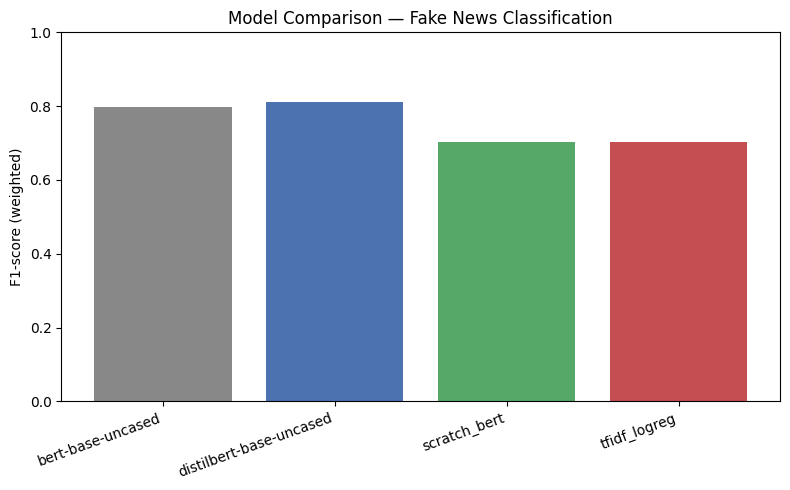

In [ ]:
# Visual comparison bar chart for the report
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(summary["model"], summary["f1_mean"], color=["#888", "#4c72b0", "#55a868", "#c44e52"])
ax.set_ylabel("F1-score (weighted)")
ax.set_title("Model Comparison — Fake News Classification")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("results/model_comparison_bar.png", dpi=150)
plt.show()


## Step 5 — Multi-seed experiment (mean ± std F1)

Runs BERT-base and DistilBERT across 3 seeds each (~40–70 min on GPU total). Skip this cell if you're short on time — Steps 3–4 alone already give you a solid report.

In [ ]:
!bash scripts/run_multiseed.sh data/fakeddit


== bert-base-uncased  seed=42 ==
Train: 4000 | Test: 1000 | train_fraction=1.0
Loading weights: 100% 199/199 [00:00<00:00, 4752.31it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	th

In [ ]:
import pandas as pd
multiseed_summary = pd.read_csv("results/multiseed/comparison_table_summary.csv")
multiseed_summary


,model,n_runs,accuracy_mean,accuracy_std,f1_mean,f1_std
0,bert-base-uncased,3,0.802333,0.010408,0.802222,0.010412
1,distilbert-base-uncased,3,0.804333,0.012423,0.804223,0.012379


## Step 6 — Data-scaling ablation

Trains BERT-base at 10% / 25% / 50% / 100% of the training set (~30–45 min on GPU). Produces the "does more data help" plot.

In [ ]:
!bash scripts/run_data_ablation.sh data/fakeddit


== bert-base-uncased  train_fraction=0.10 ==
Train: 400 | Test: 1000 | train_fraction=0.1
Loading weights: 100% 199/199 [00:00<00:00, 4078.47it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

In [ ]:
import pandas as pd
from src.evaluation.metrics import plot_data_scaling_curve

ablation_df = pd.read_csv("results/ablation/comparison_table.csv").sort_values("train_fraction")
plot_data_scaling_curve(
    ablation_df["train_fraction"].tolist(),
    ablation_df["f1"].tolist(),
    "results/ablation/scaling_curve.png",
)
ablation_df


,run_dir,model,seed,train_fraction,accuracy,precision,recall,f1
2,bert_base_frac0.10,bert-base-uncased,42,0.10,0.685,0.691630,0.685,0.682252
0,bert_base_frac0.25,bert-base-uncased,42,0.25,0.745,0.753780,0.745,0.742775
1,bert_base_frac0.50,bert-base-uncased,42,0.50,0.761,0.765772,0.761,0.759922
3,bert_base_frac1.00,bert-base-uncased,42,1.00,0.799,0.800472,0.799,0.798753


## Step 7 — Error analysis

`train_transformer.py` already saved 10 misclassified examples per fine-tuned model. Let's look at BERT-base's.

In [ ]:
import pandas as pd
errors = pd.read_csv("results/bert_base/error_examples.csv")
errors[["clean_title", "true_label", "pred_label", "error_category"]]


,clean_title,true_label,pred_label,error_category
0,ok everyone give me your best hair i want to b...,1,0,long_title
1,prime minister of canada with president of ame...,1,0,other
2,beautiful mountain in the sunrise,0,1,other
3,teddy bear scratching his ear,0,1,other
4,twa flight crashes off long island,0,1,other
5,just this,1,0,very_short_title
6,a grandmotherly figure with grey hair and dres...,0,1,long_title
7,we take out a loan with apr to see whats the w...,0,1,other
8,good things happening to good people,1,0,other
9,the surprising thing google learned about its ...,0,1,other


In [ ]:
print(errors["error_category"].value_counts())
# Read through these rows and write 3-5 sentences in your report about the
# patterns you notice (e.g. "most errors are on very short titles with no
# context", or "the model struggles with sarcastic real headlines").


error_category
other               7
long_title          2
very_short_title    1
Name: count, dtype: int64


## Step 8 — Integrated Gradients, tied to the errors

Runs IG on 3 fake + 3 real correctly-classified examples (per the assignment spec) **and** on a couple of the misclassified examples from Step 7, so you can connect token attribution directly to *why* the model got something wrong — this is the highest-value paragraph you can write in the report.

In [ ]:
import torch
import os
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from src.interpretability.integrated_gradients import compute_ig, top_k_tokens

# Use absolute path to avoid ambiguity
checkpoint_path = os.path.abspath("results/bert_base/checkpoint")

device = "cuda" if torch.cuda.is_available() else "cpu"

if not os.path.exists(checkpoint_path):
    print(f"ERROR: Checkpoint not found at {checkpoint_path}.")
    print("Please ensure Step 4 (BERT-base fine-tune) finished successfully.")
else:
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path).to(device)
    tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
    model.eval()
    print(f"Successfully loaded fine-tuned BERT-base checkpoint from {checkpoint_path}.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Successfully loaded fine-tuned BERT-base checkpoint from /content/bert-fake-news/results/bert_base/checkpoint.


In [ ]:
!pip install captum

  Using cached captum-0.9.0-py3-none-any.whl.metadata (24 kB)
Using cached captum-0.9.0-py3-none-any.whl (455 kB)


In [ ]:
import sys
import os
import importlib
import pandas as pd

# 1. Setup Environment and Diagnostics
PROJECT_ROOT = "/content/bert-fake-news"

# Ensure the path is in sys.path
abs_project_root = os.path.abspath(PROJECT_ROOT)
if abs_project_root not in sys.path:
    sys.path.insert(0, abs_project_root)

if not os.path.exists(abs_project_root) or not os.listdir(abs_project_root):
    print(f"CRITICAL ERROR: The directory {abs_project_root} is empty or missing.")
    print("ACTION REQUIRED: Please re-run all cells under 'Step 0' to write the source files to disk.")
else:
    os.chdir(abs_project_root)
    importlib.invalidate_caches()

    # 3. Import local modules
    try:
        from src.data.preprocess import prepare_dataset
        from src.interpretability.integrated_gradients import compute_ig, top_k_tokens
        print("Successfully imported local modules.")

        # 4. Process examples
        # Note: 'model', 'tokenizer', and 'device' must be defined from previous cells
        _, held_out_test_df, _ = prepare_dataset("data/fakeddit", n_per_class=2500, seed=42)

        fake_examples = held_out_test_df[held_out_test_df["label"] == 1]["clean_title"].tolist()[:3]
        real_examples = held_out_test_df[held_out_test_df["label"] == 0]["clean_title"].tolist()[:3]

        for label_name, target, examples in [("FAKE", 1, fake_examples), ("REAL", 0, real_examples)]:
            print(f"\n=== {label_name} examples ===")
            for text in examples:
                result = compute_ig(text, model, tokenizer, target_class=target, device=device, n_steps=300)
                top5 = top_k_tokens(result, k=5)
                print(f"\nText: {text}")
                print(f"Convergence delta: {result['convergence_delta']:.4f}")
                print(f"Top-5 tokens: {top5}")
    except ModuleNotFoundError as e:
        print(f"Import failed: {e}")
        print("Ensure Step 0 cells were executed to write the source files to disk.")

Successfully imported local modules.

=== FAKE examples ===

Text: katy perry shares nude snap as she plans to vote naked
Convergence delta: 0.0005
Top-5 tokens: [('nude', 0.40921929478645325), ('she', 0.37980514764785767), ('shares', 0.3116990625858307), ('vote', 0.3101275563240051), ('naked', 0.266294002532959)]

Text: otterbox iphone case not otterproof
Convergence delta: 0.0106
Top-5 tokens: [('iphone', 0.7938814163208008), ('##proof', 0.25690796971321106), ('otter', 0.2490384578704834), ('case', -0.13207608461380005), ('otter', 0.12243670225143433)]

Text: attacks in israel weigh heavily on lacrosse team
Convergence delta: 0.0058
Top-5 tokens: [('team', 0.4312763512134552), ('lacrosse', 0.39335882663726807), ('weigh', 0.2709629237651825), ('attacks', 0.16107912361621857), ('israel', 0.13162292540073395)]

=== REAL examples ===

Text: new study reveals humanity just one coexist bumper sticker away from world peace
Convergence delta: 0.0180
Top-5 tokens: [('new', 0.1720842868089676)

In [ ]:
# Now the misclassified examples from Step 7 -- this is what to write about in the report
print("=== Misclassified examples (why did the model get these wrong?) ===")
for _, row in errors.head(3).iterrows():
    text = row["clean_title"]
    predicted_class = int(row["pred_label"])
    result = compute_ig(text, model, tokenizer, target_class=predicted_class, device=device, n_steps=300)
    top5 = top_k_tokens(result, k=5)
    print(f"\nText: {text}")
    print(f"True label: {row['true_label']} | Predicted: {row['pred_label']} | Category: {row['error_category']}")
    print(f"Top-5 tokens driving the (wrong) prediction: {top5}")
    # --> Write a sentence here in your report connecting these tokens to the error.


=== Misclassified examples (why did the model get these wrong?) ===

Text: ok everyone give me your best hair i want to be beautiful again edit the shop with the most upvotes by the end of the day wins my scalp greatdanger
True label: 1 | Predicted: 0 | Category: long_title
Top-5 tokens driving the (wrong) prediction: [('##ger', -0.6201200485229492), ('wins', 0.19570554792881012), ('day', -0.17407694458961487), ('my', -0.14671868085861206), ('##vot', 0.14214852452278137)]

Text: prime minister of canada with president of america
True label: 1 | Predicted: 0 | Category: other
Top-5 tokens driving the (wrong) prediction: [('prime', -0.6232251524925232), ('minister', -0.4776725172996521), ('of', 0.1331918090581894), ('america', 0.10090645402669907), ('canada', 0.0989450216293335)]

Text: beautiful mountain in the sunrise
True label: 0 | Predicted: 1 | Category: other
Top-5 tokens driving the (wrong) prediction: [('mountain', 0.46445775032043457), ('beautiful', 0.43079838156700134), ('sunr

## Step 9 — Launch the demo

Opens an interactive Gradio UI (prediction + confidence + token-attribution highlighting). `share=True` in the app gives you a public link you can put in your resume/README, or push the checkpoint to Hugging Face Spaces for a permanent one.

In [ ]:
!python app/demo_app.py --model_dir results/bert_base/checkpoint --share


Traceback (most recent call last):
  File "/content/bert-fake-news/app/demo_app.py", line 19, in <module>
    from src.interpretability.integrated_gradients import compute_ig
ModuleNotFoundError: No module named 'src'


## Step 10 — Zip and download all results

Run this last, after whichever steps above you completed, to get everything (metrics, plots, error examples, checkpoints) as one zip you can download from Colab's file browser or via the link below.

In [ ]:
import shutil
shutil.make_archive("/content/bert_fake_news_results", "zip", "results")
print("Saved to /content/bert_fake_news_results.zip")

from google.colab import files
files.download("/content/bert_fake_news_results.zip")


Saved to /content/bert_fake_news_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### Notes
- If you only have limited Colab time, prioritize **Steps 0–5** (comparison table) and **Step 8** (Integrated Gradients) — those two give you the strongest report content for the least GPU time.
- Model checkpoints (`results/*/checkpoint/`) are large (~400MB each for BERT-base/DistilBERT) — the results zip in Step 10 excludes nothing by default, so it may be sizeable. Delete the `checkpoint/` subfolders before zipping if you only need the metrics/plots/CSVs.
- `README.md` and `NEXT_STEPS.md` were also written into `/content/bert-fake-news/` in Step 0 for reference.
